# <center>TFM — Modelado de la desviación de espesor en laminados UD y PW<center>
## <center>Aprendizaje no supervisado y supervisado<center>

**Target:** desviación porcentual del espesor curado respecto al espesor nominal

**Dataset:** 5.444 mediciones puntuales de espesor sobre 92 probetas, en 5 configuraciones
geométricas (plana, radio macho R2 y R5, radio hembra R13 y R15) y 2 materiales
(UD Tape y PW Fabric).

---
# Resumen
---

Este cuaderno desarrolla el bloque de aprendizaje automático del TFM sobre el objetivo
principal definido previamente: la **desviación porcentual del espesor curado respecto al espesor
nominal teórico**, medida punto a punto sobre las 92 probetas de la campaña experimental.

El trabajo se organiza en dos partes complementarias:

1. **Aprendizaje no supervisado**, con tres funciones concretas y acotadas: detección de
anomalías previa a la limpieza, **validación empírica de la variable `Zona`** (asignada
inicialmente por criterio geométrico a partir de los croquis de medición) y agrupación de
configuraciones por comportamiento. No se aplica como complemento decorativo: cada técnica
responde a una pregunta que el análisis supervisado no puede responder.

2. **Aprendizaje supervisado**, como núcleo del trabajo: regresión de la desviación a partir
exclusivamente de variables de diseño y proceso conocidas *antes* de medir la pieza. Se
comparan nueve algoritmos con optimización de hiperparámetros en dos fases
(`RandomizedSearchCV` → `GridSearchCV`) y **validación cruzada agrupada por probeta**, y se
cierra con interpretabilidad (importancia por permutación y SHAP) y análisis de errores.

Se presta atención explícita a dos riesgos metodológicos que condicionan la validez de todo
el bloque: la **fuga de información** derivada de la propia definición del target y la
**dependencia intra-probeta** de las mediciones, que invalidaría cualquier partición
aleatoria de los datos.

---
# 1 - Inicialización
---

In [1]:
# Imports generales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocesado y validación
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import (GroupKFold, KFold, cross_val_score,
                                     cross_val_predict, RandomizedSearchCV,
                                     GridSearchCV)

# Modelos supervisados
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              IsolationForest)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor, LocalOutlierFactor
import xgboost as xgb

# Modelos no supervisados y métricas de clustering
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score,
                             mean_absolute_error, mean_squared_error, r2_score)
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.stats import randint as sp_randint, uniform as sp_uniform

# Interpretabilidad
import shap

SEED = 42
np.random.seed(SEED)
sns.set_style('whitegrid')
PAL = ['#378ADD', '#D85A30', '#1D9E75', '#D4537E', '#8B6BB1']

In [2]:
# Carga del dataset unificado
df = pd.read_csv('dataset_espesores_unificado.csv', sep=';', decimal=',',
                 encoding='utf-8-sig')

print('== DIMENSIONES ==')
print(df.shape)
print()
print('== TIPOS DE DATOS ==')
df.info()
print()
print('== PRIMERAS FILAS ==')
df.head()

== DIMENSIONES ==
(5444, 14)

== TIPOS DE DATOS ==
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5444 entries, 0 to 5443
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PT-AU            5444 non-null   object 
 1   Nº ciclo         5444 non-null   object 
 2   Part Number      4236 non-null   object 
 3   Nº Serie         4236 non-null   object 
 4   Geometría        5444 non-null   object 
 5   Material         5444 non-null   object 
 6   Nº capas         5439 non-null   float64
 7   Sección          3203 non-null   object 
 8   Punto            5444 non-null   object 
 9   Zona             5444 non-null   object 
 10  FV               5444 non-null   object 
 11  Espesor nominal  5439 non-null   float64
 12  Espesor curado   5444 non-null   float64
 13  OF               1208 non-null   float64
dtypes: float64(4), object(10)
memory usage: 595.6+ KB

== PRIMERAS FILAS ==


,PT-AU,Nº ciclo,Part Number,Nº Serie,Geometría,Material,Nº capas,Sección,Punto,Zona,FV,Espesor nominal,Espesor curado,OF
0,PT-AU88,AU1-11193,ACTR-01900-000,1,Plana,UD Tape,8.0,NaN,P1,Alma,NO,1.152,1.20,NaN
1,PT-AU88,AU1-11193,ACTR-01900-000,1,Plana,UD Tape,8.0,NaN,P2,Alma,NO,1.152,1.22,NaN
2,PT-AU88,AU1-11193,ACTR-01900-000,1,Plana,UD Tape,8.0,NaN,P3,Alma,NO,1.152,1.22,NaN
3,PT-AU88,AU1-11193,ACTR-01900-000,1,Plana,UD Tape,8.0,NaN,P4,Alma,NO,1.152,1.22,NaN
4,PT-AU88,AU1-11193,ACTR-01900-000,1,Plana,UD Tape,8.0,NaN,P5,Alma,NO,1.152,1.20,NaN


## 1.1. Construcción del target y del identificador de agrupación

El target se define como la diferencia relativa entre el espesor medido tras el curado y
el espesor nominal teórico de la pieza:

$$\text{Desviación (\%)} = \left(\frac{e_{\text{curado}}}{e_{\text{nominal}}} - 1\right)\times 100$$

El espesor nominal se ha calculado de forma homogénea para todo el dataset como
`nº de capas × CPT`, con CPT = 0,144 mm para UD Tape y 0,200 mm para PW Fabric, más
0,063 mm cuando la probeta incorpora capa exterior de fibra de vidrio. Esta homogeneización
es imprescindible: sin ella, las distintas campañas arrastrarían valores nominales
diferentes y se introduciría un desplazamiento sistemático entre geometrías que el modelo
interpretaría como efecto físico real.

Se construye además un **identificador de probeta** (`ID_Probeta`), que será el criterio de
agrupación en toda la validación cruzada. Los puntos de una misma probeta comparten material,
utillaje, lote de curado y operario, por lo que **no son observaciones independientes**.

In [4]:
# Target
df['Desviacion_pct'] = (df['Espesor curado'] / df['Espesor nominal'] - 1) * 100

# Identificador de probeta: OF cuando existe (R13/R15), PN + nº de serie en el resto
df['ID_Probeta'] = np.where(
    df['OF'].notna(),
    'OF' + df['OF'].astype('Int64').astype(str),
    df['Part Number'].astype(str) + '_' + df['Nº Serie'].astype(str))

print(f"Filas totales          : {len(df)}")
print(f"Target con valor nulo  : {df['Desviacion_pct'].isna().sum()}")
print(f"Probetas identificadas : {df['ID_Probeta'].nunique()}")
print()
print('== PROBETAS Y MEDICIONES POR GEOMETRÍA ==')
print(df.groupby('Geometría').agg(
    Mediciones=('Desviacion_pct', 'size'),
    Probetas=('ID_Probeta', 'nunique')).to_string())
print()
print('== PUNTOS POR PROBETA ==')
print(df.groupby('ID_Probeta').size().describe().round(1).to_string())

Filas totales          : 5444
Target con valor nulo  : 5
Probetas identificadas : 92

== PROBETAS Y MEDICIONES POR GEOMETRÍA ==
            Mediciones  Probetas
Geometría                       
Plana             2241        20
R13 hembra         920        34
R15 hembra         288        12
R2 macho          1155        12
R5 macho           840        14

== PUNTOS POR PROBETA ==
count     92.0
mean      59.2
std       39.7
min       20.0
25%       28.0
50%       48.0
75%       81.8
max      154.0


**Análisis de la estructura del dataset**

El dataset contiene 5.444 mediciones, pero estas se reparten sobre **únicamente 92 probetas
físicas**. Esta distinción es la más importante de todo el trabajo desde el punto de vista
metodológico: el número de observaciones sugiere un dataset de tamaño medio, pero el número
de **unidades experimentales independientes** es dos órdenes de magnitud menor.

El desequilibrio es además notable: las probetas planas concentran 2.241 mediciones sobre
20 probetas (112 puntos de media por probeta, al medirse 32 puntos en cada zona de distinto
espesor), mientras que R15 aporta 288 mediciones sobre 12 probetas. Esto obliga a
interpretar con cautela cualquier métrica global y a agrupar la validación por probeta.

Los 5 valores nulos del target corresponden a registros sin número de capas identificado,
por lo que su nominal no ha podido calcularse.

---
# 2 - Exploración del target
---

In [5]:
d = df.dropna(subset=['Desviacion_pct']).copy()

print('== ESTADÍSTICOS GLOBALES ==')
print(d['Desviacion_pct'].describe().round(3).to_string())
print()
print('== POR GEOMETRÍA ==')
print(d.groupby('Geometría')['Desviacion_pct'].describe().round(2).to_string())
print()
print('== POR ZONA ==')
print(d.groupby('Zona')['Desviacion_pct'].describe().round(2).to_string())
print()
print('== POR MATERIAL ==')
print(d.groupby('Material')['Desviacion_pct'].describe().round(2).to_string())

== ESTADÍSTICOS GLOBALES ==
count    5439.000
mean        3.461
std         5.306
min       -22.955
25%         0.000
50%         2.500
75%         6.250
max       142.622

== POR GEOMETRÍA ==
             count  mean   std    min   25%   50%   75%     max
Geometría                                                      
Plana       2236.0  6.77  5.75 -15.41  3.68  6.34  9.38  142.62
R13 hembra   920.0  1.51  3.91 -22.95 -1.04  0.68  3.57   30.21
R15 hembra   288.0 -0.48  2.37  -8.85 -1.91 -0.36  0.71    8.75
R2 macho    1155.0  2.07  3.50 -10.00  0.00  1.79  4.17   29.29
R5 macho     840.0  0.05  2.43  -8.75 -1.33  0.00  1.38   11.25

== POR ZONA ==
           count  mean   std    min   25%   50%   75%     max
Zona                                                         
Alma      3535.0  4.60  5.70 -22.95  0.69  4.17  7.64  142.62
Faldilla  1370.0  0.70  2.92 -10.00 -1.04  0.38  2.43   12.41
Radio      534.0  3.01  4.59  -9.72  0.00  2.50  5.45   29.29

== POR MATERIAL ==
            c

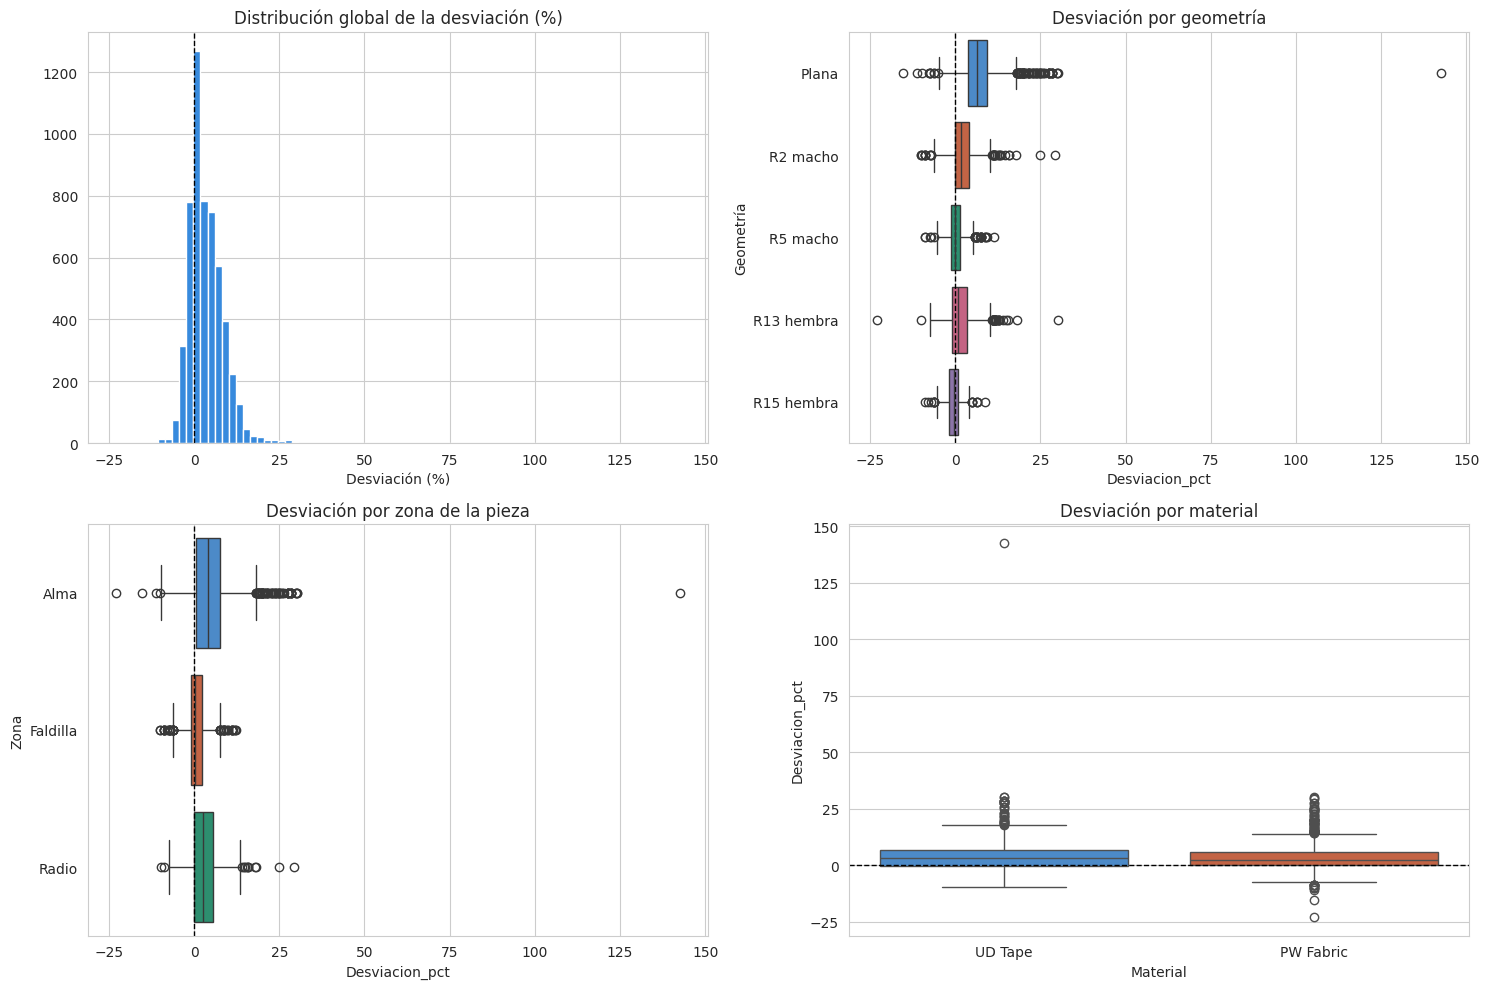

In [6]:
# Distribución del target: global y por subgrupos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0,0].hist(d['Desviacion_pct'], bins=80, color=PAL[0], edgecolor='white')
axes[0,0].axvline(0, color='k', ls='--', lw=1)
axes[0,0].set_title('Distribución global de la desviación (%)')
axes[0,0].set_xlabel('Desviación (%)')

sns.boxplot(data=d, y='Geometría', x='Desviacion_pct', ax=axes[0,1],
            palette=PAL, orient='h')
axes[0,1].axvline(0, color='k', ls='--', lw=1)
axes[0,1].set_title('Desviación por geometría')

sns.boxplot(data=d, y='Zona', x='Desviacion_pct', ax=axes[1,0],
            palette=PAL[:3], orient='h')
axes[1,0].axvline(0, color='k', ls='--', lw=1)
axes[1,0].set_title('Desviación por zona de la pieza')

sns.boxplot(data=d, x='Material', y='Desviacion_pct', hue='Material',
            ax=axes[1,1], palette=PAL[:2], legend=False)
axes[1,1].axhline(0, color='k', ls='--', lw=1)
axes[1,1].set_title('Desviación por material')

plt.tight_layout(); plt.show()

**Análisis de la distribución del target**

La desviación media global es de +3,46 %, es decir, **existe un sesgo sistemático hacia el
sobreespesor**: las piezas curadas resultan de media más gruesas que su nominal teórico.
Este sesgo no es homogéneo entre geometrías, y ahí reside la primera fuente de señal
aprovechable por el modelo:

* **Probetas planas**: media +6,77 % con desviación típica 5,75. Son con diferencia el grupo
  de mayor desviación y mayor dispersión, y contienen el valor extremo del dataset
  (+142,62 %).
* **R2 macho**: media +2,07 %.
* **R13 hembra**: media +1,51 %, con la mayor amplitud negativa (−22,95 %).
* **R5 macho**: media +0,05 %, prácticamente centrado.
* **R15 hembra**: media −0,48 %, el único grupo con sesgo negativo (subespesor).

Por zonas, el alma presenta la mayor desviación media (+4,60 %) y el radio la segunda
(+3,01 %), mientras que la faldilla está casi centrada (+0,70 %). Debe señalarse que la
comparación por zona está **contaminada por la geometría**: como en probetas planas todos
los puntos son alma y las planas son el grupo de mayor desviación, la zona «alma» hereda
ese efecto. El análisis por zona solo es interpretable *dentro* de cada geometría curva,
como se hará en la sección de aprendizaje no supervisado.

Por material, UD Tape (+3,72 %) supera ligeramente a PW Fabric (+3,17 %), pero esta
diferencia debe interpretarse con extrema cautela por el motivo que se analiza a
continuación.

## 2.1. Confusión estructural entre material y número de capas

In [7]:
print('== TABLA DE CONTINGENCIA: Nº DE CAPAS x MATERIAL ==')
print(pd.crosstab(d['Nº capas'], d['Material']).to_string())
print()
print('== ESPESOR NOMINAL POR MATERIAL ==')
print(d.groupby('Material')['Espesor nominal'].agg(['min', 'max', 'nunique']).to_string())
print()
print('== NOMINALES ÚNICOS ORDENADOS ==')
print(d[['Material', 'Nº capas', 'Espesor nominal']].drop_duplicates()
      .sort_values('Espesor nominal').to_string(index=False))

== TABLA DE CONTINGENCIA: Nº DE CAPAS x MATERIAL ==
Material  PW Fabric  UD Tape
Nº capas                    
4.0             862        0
8.0               0      883
14.0            851        0
16.0              0      779
22.0            819        0
24.0              0      673
52.0              0      572

== ESPESOR NOMINAL POR MATERIAL ==
             min    max  nunique
Material                        
PW Fabric  0.800  4.463        6
UD Tape    1.152  7.551        8

== NOMINALES ÚNICOS ORDENADOS ==
 Material  Nº capas  Espesor nominal
PW Fabric       4.0            0.800
PW Fabric       4.0            0.863
  UD Tape       8.0            1.152
  UD Tape       8.0            1.215
  UD Tape      16.0            2.304
  UD Tape      16.0            2.367
PW Fabric      14.0            2.800
PW Fabric      14.0            2.863
  UD Tape      24.0            3.456
  UD Tape      24.0            3.519
PW Fabric      22.0            4.400
PW Fabric      22.0            4.463
  UD

La tabla de contingencia revela una limitación fundamental del diseño experimental que
condiciona toda la interpretación posterior: **no existe ningún solapamiento entre los
números de capa de ambos materiales**. UD Tape se ensaya únicamente con 8, 16, 24 y 52
capas; PW Fabric únicamente con 4, 14 y 22. La celda cruzada está vacía en todos los casos.

La consecuencia es directa e ineludible: **es imposible separar estadísticamente el efecto
del material del efecto del número de capas**. Cualquier diferencia observada entre UD Tape
y PW Fabric puede deberse al material, al número de capas, o a cualquier combinación de
ambos, sin que los datos permitan discriminar. Esta limitación debe declararse
explícitamente y no puede resolverse con ninguna técnica de modelado: es una restricción
del diseño de la campaña, no del análisis.

Existe, sin embargo, una vía parcial de solución. Los **espesores nominales sí se
entrelazan** entre materiales: 0,80 mm (PW, 4 capas) < 1,15 mm (UD, 8) < 2,80 mm (PW, 14)
< 3,46 mm (UD, 24) < 4,40 mm (PW, 22) < 7,49 mm (UD, 52). Por tanto, el **espesor nominal
del laminado, como variable continua, no está confundido con el material** y constituye una
característica físicamente más significativa que el recuento de capas. Por este motivo se
incorpora como variable numérica principal en todos los modelos.

---
# 3 - Preprocesado y control de fuga de información
---

Antes de modelar es imprescindible fijar qué variables pueden actuar como predictores.
El target se define como un cociente en el que intervienen `Espesor curado` y
`Espesor nominal`, de modo que la selección de características no es una decisión de
conveniencia sino de validez.

**`Espesor curado` queda excluido de forma absoluta.** Es el numerador del target: incluirlo
permite al modelo reconstruir la variable objetivo por definición, produciendo métricas
excelentes y completamente vacías de contenido. Este punto se demuestra numéricamente en
la sección 5.1.

**`Espesor nominal` sí se incluye.** A diferencia del anterior, es una variable de diseño
conocida antes de fabricar la pieza (se deriva del material y del número de capas
proyectados), no requiere medición alguna y no permite recuperar el espesor curado por sí
sola. Su inclusión es además físicamente pertinente, ya que el espesor del laminado
condiciona la compactación.

Se definen tres conjuntos de características de complejidad creciente, para cuantificar
cuánto aporta cada bloque de información:

* **A1 — diseño mínimo:** espesor nominal, material, geometría, zona y presencia de fibra
  de vidrio.
* **A2 — diseño completo:** añade número de capas, indicador binario de radio, punto y
  sección de medición.
* **B — diseño + proceso:** añade el perfil de curado (`PT-AU`) y el lote concreto de
  autoclave (`Nº ciclo`).

La distinción entre A y B no es arbitraria. El conjunto B responde a una pregunta distinta:
*¿cuánto mejora la predicción si además se conoce el lote de curado?* Y arrastra un riesgo
que conviene anticipar: al haber sólo 12 lotes para 92 probetas, y estar cada lote anidado
dentro de una única geometría, el modelo puede memorizar la media de cada lote en lugar de
aprender una relación generalizable.

In [13]:
# Variables derivadas para el modelado
d['Es_radio']  = (d['Zona'] == 'Radio').astype(int)      # zona binaria (ver sección 4.2)
d['Seccion_f'] = d['Sección'].fillna('NA')               # nulo estructural en planas
d['Punto_geo'] = d['Geometría'].str[:3] + '_' + d['Punto'].astype(str)

TARGET = 'Desviacion_pct'
GROUP  = 'ID_Probeta'

SETS = {
    'A1 diseño mínimo':   (['Espesor nominal'],
                           ['Material', 'Geometría', 'Zona', 'FV']),
    'A2 diseño completo': (['Espesor nominal', 'Nº capas', 'Es_radio'],
                           ['Material', 'Geometría', 'Zona', 'FV',
                            'Punto_geo', 'Seccion_f']),
    'B diseño + proceso': (['Espesor nominal', 'Nº capas', 'Es_radio'],
                           ['Material', 'Geometría', 'Zona', 'FV',
                            'Punto_geo', 'Seccion_f', 'PT-AU', 'Nº ciclo']),
}

# Anidamiento de los ciclos de curado dentro de la geometría
print('== Nº CICLO x GEOMETRÍA ==')
print(pd.crosstab(d['Geometría'], d['Nº ciclo']).to_string())
print()
print('== PT-AU x GEOMETRÍA ==')
print(pd.crosstab(d['Geometría'], d['PT-AU']).to_string())

== Nº CICLO x GEOMETRÍA ==
Nº ciclo    11203  3421  3442  AU01-3421  AU01-3442  AU1-11190  AU1-11193  AU1-11236  AU1-11349  AU1-3463  AU3-3421  AU3-3458
Geometría                                                                                                                    
Plana           0     0     0          0          0        672        673        443          0         0       448         0
R13 hembra      0     0     0        364        556          0          0          0          0         0         0         0
R15 hembra      0     0     0          0          0          0          0          0          0       288         0         0
R2 macho      385   385   385          0          0          0          0          0          0         0         0         0
R5 macho        0     0     0          0          0          0          0          0        408         0         0       432

== PT-AU x GEOMETRÍA ==
PT-AU       PT-AU15  PT-AU57  PT-AU88  PT-AU89
Geometría          

**Análisis del anidamiento de los lotes de curado**

Las tablas confirman que cada ciclo concreto de curado pertenece a una única
geometría. No hay ningún ciclo compartido entre geometrías distintas, de modo que
`Nº ciclo` actúa en la práctica como un identificador más fino de la geometría, con
información añadida de lote. Con validación agrupada por probeta, un mismo lote puede
aparecer en entrenamiento y en test (a través de probetas distintas), permitiendo al modelo
transferir la media del lote. Esto no es fuga en sentido estricto (en producción el lote es
conocido), pero infla el rendimiento aparente respecto a la capacidad de generalizar a
lotes nuevos.

`PT-AU` presenta cierto solapamiento (PT-AU57 aparece en planas, R2 y R13), por lo que es
algo menos problemático.

In [14]:
# Pipeline de preprocesado: escalado opcional de numéricas + one-hot de categóricas
def make_prep(num, cat, scale=False):
    return ColumnTransformer([
        ('num', StandardScaler() if scale else 'passthrough', num),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat)])

def evaluar(model, X, y, groups, num, cat, scale=False, n_splits=5):
    """Validación cruzada AGRUPADA POR PROBETA. Devuelve MAE, RMSE y R2."""
    pipe = Pipeline([('prep', make_prep(num, cat, scale)), ('mod', model)])
    cv = GroupKFold(n_splits=n_splits)
    mae, rmse, r2 = [], [], []
    for tr, te in cv.split(X, y, groups):
        pipe.fit(X.iloc[tr], y.iloc[tr])
        p = pipe.predict(X.iloc[te])
        mae.append(mean_absolute_error(y.iloc[te], p))
        rmse.append(np.sqrt(mean_squared_error(y.iloc[te], p)))
        r2.append(r2_score(y.iloc[te], p))
    return dict(MAE=np.mean(mae), MAE_sd=np.std(mae), RMSE=np.mean(rmse),
                R2=np.mean(r2), R2_sd=np.std(r2))

y = d[TARGET]
g = d[GROUP]
cv = GroupKFold(n_splits=5)
print('Preprocesado y función de evaluación definidos.')
print(f'Validación: GroupKFold(5) agrupando por {GROUP} ({g.nunique()} grupos)')

Preprocesado y función de evaluación definidos.
Validación: GroupKFold(5) agrupando por ID_Probeta (92 grupos)


---
# 4 - PARTE I: APRENDIZAJE NO SUPERVISADO
---

El aprendizaje no supervisado se aplica aquí con tres finalidades acotadas, cada una
respondiendo a una pregunta que el modelo supervisado no puede responder:

1. **Detección de anomalías**: identificar de forma objetiva mediciones sospechosas
   antes de la fase de limpieza, distinguiendo error de medición de defecto real.
2. **Validación de la variable `Zona`**: las etiquetas alma/radio/faldilla se
   asignaron *a priori* desde los croquis de medición, es decir, son una **hipótesis
   geométrica**. El clustering permite contrastar si esa estructura existe realmente en los
   datos.
3. **Agrupación de configuraciones**: identificar familias de comportamiento entre
   las 92 probetas.

Se justifica también, por qué se descarta la reducción de dimensionalidad.

## 4.1. Detección de anomalías

In [15]:
# Espacio de trabajo: escala del laminado + comportamiento observado
Xa = StandardScaler().fit_transform(d[['Espesor nominal', 'Desviacion_pct']])

iso = IsolationForest(contamination=0.01, random_state=SEED, n_estimators=300)
d['iso'] = iso.fit_predict(Xa)

lof = LocalOutlierFactor(n_neighbors=25, contamination=0.01)
d['lof'] = lof.fit_predict(Xa)

# Referencia clásica: IQR calculado dentro de cada combinación geometría + zona
def iqr_flag(s):
    q1, q3 = s.quantile(.25), s.quantile(.75)
    i = q3 - q1
    return (s < q1 - 1.5*i) | (s > q3 + 1.5*i)

d['iqr'] = d.groupby(['Geometría', 'Zona'])['Desviacion_pct'].transform(iqr_flag)

print(f"Isolation Forest : {(d['iso']==-1).sum():4d} anomalías")
print(f"LOF              : {(d['lof']==-1).sum():4d} anomalías")
print(f"IQR (geom+zona)  : {d['iqr'].sum():4d} anomalías")
print(f"Consenso IF+LOF  : {((d['iso']==-1)&(d['lof']==-1)).sum():4d} anomalías")
print()
for nom, col in [('Isolation Forest', 'iso'), ('LOF', 'lof')]:
    s = d[d[col] == -1]
    print(f"{nom}:")
    print(f"   |desviación| media = {s['Desviacion_pct'].abs().mean():6.2f} %"
          f"   máx = {s['Desviacion_pct'].abs().max():6.2f} %")
    print(f"   nominales implicados: {sorted(s['Espesor nominal'].unique())}")
    print(f"   geometrías: {dict(s['Geometría'].value_counts())}")
    print()

Isolation Forest :   54 anomalías
LOF              :   50 anomalías
IQR (geom+zona)  :  198 anomalías
Consenso IF+LOF  :    0 anomalías

Isolation Forest:
   |desviación| media =  24.46 %   máx = 142.62 %
   nominales implicados: [np.float64(0.8), np.float64(0.863), np.float64(1.152), np.float64(1.215), np.float64(2.304), np.float64(2.367), np.float64(2.8), np.float64(7.488), np.float64(7.551)]
   geometrías: {'Plana': np.int64(51), 'R2 macho': np.int64(2), 'R13 hembra': np.int64(1)}

LOF:
   |desviación| media =   2.72 %   máx =   4.53 %
   nominales implicados: [np.float64(0.863), np.float64(1.215)]
   geometrías: {'Plana': np.int64(50)}



**Análisis de la discrepancia entre Isolation Forest y LOF**

El resultado más llamativo es que **el consenso estricto entre ambos métodos es vacío**: no
hay ni un solo registro señalado simultáneamente por Isolation Forest y por LOF. Lejos de
ser un fallo, esto revela que ambos algoritmos están midiendo cosas distintas, y conviene
entender qué:

* **Isolation Forest** selecciona 54 registros con desviación absoluta media del 24,46 % y
  máxima del 142,62 %. Detecta la **cola global de la distribución**, es decir, valores
  anómalos en magnitud. Se reparten entre planas (51), R2 (2) y R13 (1), y afectan a
  nominales muy diversos.
* **LOF** selecciona 50 registros con desviación absoluta media de sólo 2,72 % y máxima de
  4,53 %, todos ellos en probetas planas y **únicamente en dos nominales concretos**
  (0,863 y 1,215 mm, precisamente las variantes con capa de fibra de vidrio de los
  laminados más finos). Detecta **aislamiento por baja densidad local**: configuraciones
  poco representadas en el dataset, no valores extremos.
* El **IQR clásico** por geometría y zona marca 198 registros, casi cuatro veces más que
  los métodos multivariantes, lo que refleja su conocida tendencia a sobredetectar en
  distribuciones asimétricas.

La conclusión metodológica es que **no deben combinarse por consenso**: Isolation Forest es
la herramienta adecuada para el objetivo perseguido aquí (localizar mediciones
potencialmente erróneas), mientras que LOF está señalando en realidad un problema distinto
y también relevante (el desequilibrio de cobertura del diseño experimental) que se trata
como limitación.

In [16]:
# Inspección del registro más extremo y de sus vecinos en la misma probeta
top = d.reindex(d['Desviacion_pct'].abs().sort_values(ascending=False).index).head(6)
print('== SEIS DESVIACIONES MÁS EXTREMAS ==')
print(top[['ID_Probeta','Geometría','Material','Nº capas','Punto','Zona',
           'Espesor nominal','Espesor curado','Desviacion_pct']].round(2).to_string(index=False))

o = d['Desviacion_pct'].abs().idxmax()
print()
print(f"Registro extremo: {d.loc[o,'Espesor curado']} mm medidos frente a "
      f"{d.loc[o,'Espesor nominal']} mm nominales ({d.loc[o,'Desviacion_pct']:.1f} %)")
print()
print('== TODOS LOS PUNTOS DE ESA MISMA PROBETA Y ZONA DE ESPESOR ==')
v = d[(d['ID_Probeta'] == d.loc[o,'ID_Probeta']) & (d['Nº capas'] == d.loc[o,'Nº capas'])]
print(v[['Punto','Espesor curado','Desviacion_pct']].head(12).round(2).to_string(index=False))

== SEIS DESVIACIONES MÁS EXTREMAS ==
      ID_Probeta  Geometría  Material  Nº capas Punto  Zona  Espesor nominal  Espesor curado  Desviacion_pct
ACTR-01900-001_1      Plana   UD Tape      16.0    P6  Alma             2.30            5.59          142.62
ACTR-01900-000_3      Plana   UD Tape       8.0   P10  Alma             1.15            1.50           30.21
    OF1002261869 R13 hembra   UD Tape       8.0   P07  Alma             1.15            1.50           30.21
ACTR-01900-003_1      Plana PW Fabric       4.0    P4  Alma             0.80            1.04           30.00
ACTR-01900-003_1      Plana PW Fabric       4.0   P18  Alma             0.86            1.12           29.78
ACTR-01900-110_3   R2 macho PW Fabric      14.0   P08 Radio             2.80            3.62           29.29

Registro extremo: 5.59 mm medidos frente a 2.304 mm nominales (142.6 %)

== TODOS LOS PUNTOS DE ESA MISMA PROBETA Y ZONA DE ESPESOR ==
Punto  Espesor curado  Desviacion_pct
   P1            2.62     

**Análisis del registro extremo: error de medición confirmado**

El valor de +142,62 % corresponde a un punto de la probeta plana `ACTR-01900-001_1`
(UD Tape, 16 capas) con un espesor medido de **5,59 mm frente a 2,304 mm nominales**. La
inspección de sus vecinos inmediatos —los otros once puntos de la misma probeta y la misma
zona de espesor— resulta concluyente: todos ellos se sitúan entre 2,50 y 2,66 mm, con
desviaciones del 8-15 %.

Un punto que mide más del doble que sus vecinos contiguos en una pieza plana no admite
explicación física plausible: no hay mecanismo de compactación que produzca semejante
discontinuidad local. Se trata con práctica certeza de un **error de transcripción** (5,59
frente a un probable 2,59). Este es exactamente el tipo de hallazgo que justifica ejecutar
la detección de anomalías antes del modelado, y no como comprobación posterior.

Su exclusión reduce la desviación típica global de 5,31 a 4,96 puntos porcentuales, es
decir, **un único registro sobre 5.439 explicaba el 6,6 % de la dispersión total**. El
resto de valores extremos (en torno a ±30 %) sí resultan físicamente admisibles y se
conservan, ya que pueden corresponder a defectos reales de fabricación y no a errores de medida.

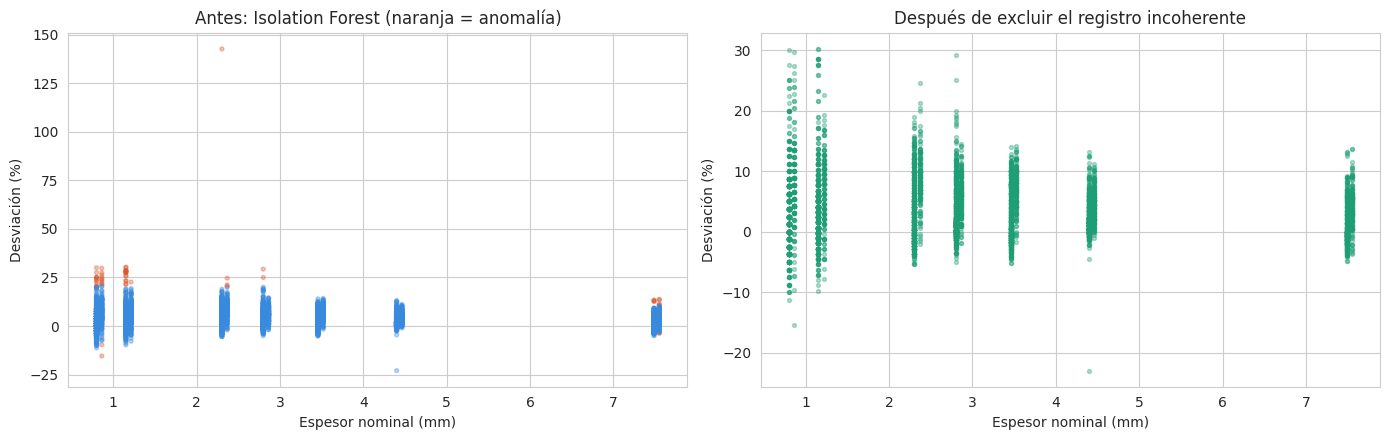

Media  : 3.46 %  ->  3.44 %
Desv.  : 5.31    ->  4.96
Dataset de trabajo: 5438 filas, 92 probetas


In [17]:
# Se excluye únicamente el registro incoherente; el resto de extremos se conserva
dc = d.drop(index=o).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].scatter(d['Espesor nominal'], d['Desviacion_pct'], s=8, alpha=.35,
                c=np.where(d['iso']==-1, PAL[1], PAL[0]))
axes[0].set_title('Antes: Isolation Forest (naranja = anomalía)')
axes[0].set_xlabel('Espesor nominal (mm)'); axes[0].set_ylabel('Desviación (%)')

axes[1].scatter(dc['Espesor nominal'], dc['Desviacion_pct'], s=8, alpha=.35, c=PAL[2])
axes[1].set_title('Después de excluir el registro incoherente')
axes[1].set_xlabel('Espesor nominal (mm)'); axes[1].set_ylabel('Desviación (%)')
plt.tight_layout(); plt.show()

print(f"Media  : {d['Desviacion_pct'].mean():.2f} %  ->  {dc['Desviacion_pct'].mean():.2f} %")
print(f"Desv.  : {d['Desviacion_pct'].std():.2f}    ->  {dc['Desviacion_pct'].std():.2f}")
print(f"Dataset de trabajo: {len(dc)} filas, {dc['ID_Probeta'].nunique()} probetas")

## 4.2. Validación empírica de la variable `Zona`

Esta sección aborda la aportación más relevante del bloque no supervisado. La variable
`Zona` (alma / radio / faldilla) **no procede de los datos**: se asignó punto por punto a
partir de los croquis de medición, es decir, es una hipótesis basada en la geometría del
utillaje. La pregunta que se plantea es si esa estructura de tres zonas **existe
efectivamente en el comportamiento medido**.

Para responderla se emplea la técnica del **dataset traspuesto**: en lugar de tratar cada
medición como un objeto, se trata cada **punto de medición** como un objeto cuyas
coordenadas son su desviación media en cada una de las probetas de esa geometría. Si el
clustering sobre ese espacio recupera la partición alma/radio/faldilla, la asignación queda
confirmada empíricamente; si no, la hipótesis geométrica debe revisarse.

La concordancia se cuantifica mediante el **índice Rand ajustado (ARI)**, que vale 1 en
caso de coincidencia perfecta y 0 en caso de coincidencia equivalente al azar. Se contrastan
dos hipótesis alternativas: la partición en **3 zonas** del croquis y una partición
simplificada en **2 zonas** (radio frente a no-radio).

In [18]:
resumen = []
detalle = {}

for geo in ['R2 macho', 'R5 macho', 'R13 hembra', 'R15 hembra']:
    sub = dc[dc['Geometría'] == geo]
    # Matriz puntos x probetas (promediando secciones)
    M = sub.pivot_table(index='Punto', columns='ID_Probeta',
                        values='Desviacion_pct', aggfunc='mean').dropna(axis=1, how='any')
    zona3 = sub.groupby('Punto')['Zona'].first().reindex(M.index)
    zona2 = np.where(zona3 == 'Radio', 'Radio', 'No radio')
    Xp = StandardScaler().fit_transform(M.values)

    fila = {'Geometría': geo, 'Puntos': M.shape[0], 'Probetas': M.shape[1]}
    for k, etq, nom in [(3, zona3, '3 clases'), (2, zona2, '2 clases')]:
        km = KMeans(n_clusters=k, random_state=SEED, n_init=50).fit_predict(Xp)
        ag = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(Xp)
        fila[f'ARI KM {nom}']   = round(adjusted_rand_score(etq, km), 3)
        fila[f'ARI Ward {nom}'] = round(adjusted_rand_score(etq, ag), 3)
        fila[f'Sil k={k}']      = round(silhouette_score(Xp, km), 3)
        if k == 3:
            detalle[geo] = pd.DataFrame({'Punto': M.index,
                                         'Zona (croquis)': zona3.values,
                                         'Clúster K-Means': km,
                                         'Clúster Ward': ag})
    resumen.append(fila)

for geo, t in detalle.items():
    print(f'--- {geo} (k=3) ---')
    print(t.to_string(index=False)); print()

r = pd.DataFrame(resumen)
print('== RESUMEN DE CONCORDANCIA (ARI) ==')
print(r.to_string(index=False))
print()
print(f"ARI medio 3 clases : K-Means={r['ARI KM 3 clases'].mean():.3f}  "
      f"Ward={r['ARI Ward 3 clases'].mean():.3f}")
print(f"ARI medio 2 clases : K-Means={r['ARI KM 2 clases'].mean():.3f}  "
      f"Ward={r['ARI Ward 2 clases'].mean():.3f}")

--- R2 macho (k=3) ---
Punto Zona (croquis)  Clúster K-Means  Clúster Ward
  P01       Faldilla                2             2
  P02       Faldilla                0             0
  P03       Faldilla                0             0
  P04          Radio                1             1
  P05           Alma                0             0
  P06           Alma                0             0
  P07           Alma                0             0
  P08          Radio                1             1
  P09       Faldilla                0             0
  P10       Faldilla                0             0
  P11       Faldilla                2             2

--- R5 macho (k=3) ---
Punto Zona (croquis)  Clúster K-Means  Clúster Ward
  P01           Alma                2             0
  P02           Alma                0             0
  P03           Alma                0             0
  P04          Radio                1             1
  P05       Faldilla                0             0
  P06       Faldi

**Análisis: la partición de tres zonas no se sostiene, la de dos es exacta**

El resultado es inequívoco y constituye el hallazgo más sólido del bloque no supervisado:

* Frente a la partición en **3 zonas** del croquis, el ARI medio es de apenas **0,138**
  (K-Means) y **0,246** (Ward), con un caso incluso negativo (R5 macho, ARI = −0,023, peor
  que el azar). **La estructura de tres zonas no está respaldada por los datos.**
* Frente a la partición en **2 zonas** (radio / no-radio), el ARI es **exactamente 1,000 en
  las cuatro geometrías y con ambos algoritmos**. La coincidencia es perfecta.

La lectura conjunta de las tablas de detalle explica el porqué. En las cuatro geometrías,
el clustering **aísla sistemáticamente y sin error los puntos de radio** (P04 y P08 en R2,
P04 en R5, P04 en R13, P03 en R15) asignándolos a un clúster propio. Lo que el clustering
no consigue es separar alma de faldilla: ambas caen en el mismo grupo. El tercer clúster
que emerge no corresponde a una zona, sino a los **puntos de borde** (P01 y P11 en R2, P06
en R5, P07 en R13, P06 en R15), lo que apunta a un efecto de extremo libre distinto del
efecto de zona.

La interpretación física es coherente: el radio es el único punto donde el mecanismo de
consolidación difiere cualitativamente (compactación restringida por la curvatura del
utillaje), mientras que alma y faldilla son ambas superficies planas sometidas a
condiciones equivalentes de presión, por lo que se comportan de forma estadísticamente
indistinguible.

**Consecuencia para el modelado:** se conserva `Zona` con sus tres niveles por su valor
descriptivo e interpretativo desde la ingeniería, pero se incorpora además la variable
binaria `Es_radio`, que es la que el análisis no supervisado respalda empíricamente. La
importancia relativa de ambas se contrastará en la sección de interpretabilidad.

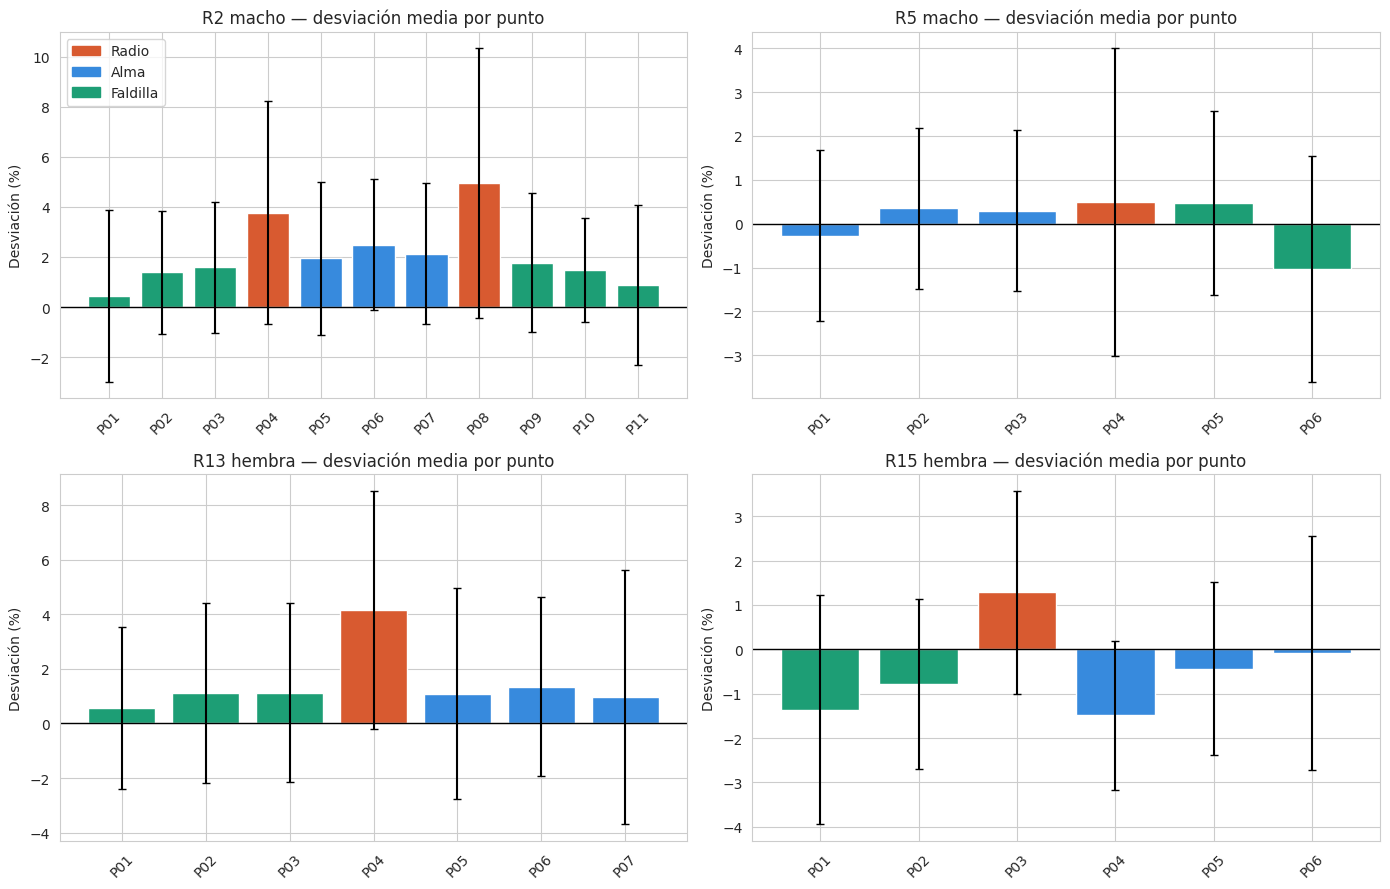

--- R2 macho ---
                mean   std
Punto Zona                
P01   Faldilla  0.44  3.42
P02   Faldilla  1.39  2.45
P03   Faldilla  1.58  2.61
P04   Radio     3.77  4.44
P05   Alma      1.95  3.05
P06   Alma      2.49  2.62
P07   Alma      2.13  2.81
P08   Radio     4.94  5.39
P09   Faldilla  1.76  2.78
P10   Faldilla  1.47  2.08
P11   Faldilla  0.89  3.18

--- R5 macho ---
                mean   std
Punto Zona                
P01   Alma     -0.27  1.95
P02   Alma      0.35  1.83
P03   Alma      0.29  1.84
P04   Radio     0.49  3.50
P05   Faldilla  0.47  2.10
P06   Faldilla -1.03  2.57

--- R13 hembra ---
                mean   std
Punto Zona                
P01   Faldilla  0.57  2.98
P02   Faldilla  1.12  3.29
P03   Faldilla  1.13  3.29
P04   Radio     4.16  4.36
P05   Alma      1.09  3.86
P06   Alma      1.35  3.29
P07   Alma      0.97  4.67

--- R15 hembra ---
                mean   std
Punto Zona                
P01   Faldilla -1.36  2.58
P02   Faldilla -0.78  1.91
P03   R

In [19]:
# Desviación media por punto: comprobación numérica del efecto radio
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, geo in zip(axes.flatten(), ['R2 macho','R5 macho','R13 hembra','R15 hembra']):
    sub = dc[dc['Geometría'] == geo]
    t = sub.groupby(['Punto','Zona'])['Desviacion_pct'].agg(['mean','std']).reset_index()
    col = t['Zona'].map({'Radio': PAL[1], 'Alma': PAL[0], 'Faldilla': PAL[2]})
    ax.bar(t['Punto'], t['mean'], yerr=t['std'], color=col, edgecolor='white', capsize=3)
    ax.axhline(0, color='k', lw=1)
    ax.set_title(f'{geo} — desviación media por punto')
    ax.set_ylabel('Desviación (%)')
    ax.tick_params(axis='x', rotation=45)

import matplotlib.patches as mpatches
axes[0,0].legend(handles=[mpatches.Patch(color=PAL[1], label='Radio'),
                          mpatches.Patch(color=PAL[0], label='Alma'),
                          mpatches.Patch(color=PAL[2], label='Faldilla')], loc='upper left')
plt.tight_layout(); plt.show()

for geo in ['R2 macho','R5 macho','R13 hembra','R15 hembra']:
    sub = dc[dc['Geometría'] == geo]
    print(f'--- {geo} ---')
    print(sub.groupby(['Punto','Zona'])['Desviacion_pct'].agg(['mean','std']).round(2).to_string())
    print()

**Análisis del efecto radio punto por punto**

Los gráficos confirman visualmente el resultado del clustering. En las cuatro geometrías el
punto de radio destaca por encima de sus vecinos:

* **R2 macho**: P04 = +3,77 % y P08 = +4,94 %, frente a 1,95-2,49 % en el alma y
  0,44-1,76 % en la faldilla. Los dos puntos de radio son los dos valores más altos de la
  sección.
* **R13 hembra**: P04 = +4,16 %, aproximadamente el triple que cualquier otro punto
  (0,57-1,35 %). Es el efecto radio más marcado del dataset.
* **R15 hembra**: P03 = +1,28 %, el único punto positivo en una geometría cuya media global
  es negativa (−0,48 %).
* **R5 macho**: P04 = +0,49 %, el efecto más débil, coherente con ser el radio más suave
  entre los machos y con presentar también la mayor desviación típica (3,50).

Se observa además, de forma consistente, que **los puntos de radio presentan la mayor
dispersión** de su respectiva geometría, lo que indica que el radio no sólo desplaza la
media sino que **degrada la repetibilidad del proceso**. Este es un resultado de valor
industrial directo: las zonas de radio son las críticas tanto en desviación media como en
variabilidad.

Por último, el contraste entre radio macho y hembra es coherente con la física esperada: en
las geometrías hembra (cóncavas) el radio muestra sobreespesor por acumulación de material,
mientras que la magnitud es menor en las machos (convexas), donde la fibra tiende a
tensarse. Debe matizarse, no obstante, que R2 presenta valores elevados en el radio pese a
ser macho, probablemente por su radio muy cerrado (2 mm) y su sección en U.

## 4.3. Agrupación de configuraciones por comportamiento

Probetas caracterizadas: 142

== MÉTRICAS INTERNAS DE CLUSTERING ==
 k  Silhouette  Davies-Bouldin  Calinski-H
 2       0.382           1.044        92.9
 3       0.304           1.177        84.8
 4       0.365           0.934        88.0
 5       0.392           0.867        94.1
 6       0.399           0.865        97.0
 7       0.416           0.773       103.9
 8       0.360           0.860       100.8


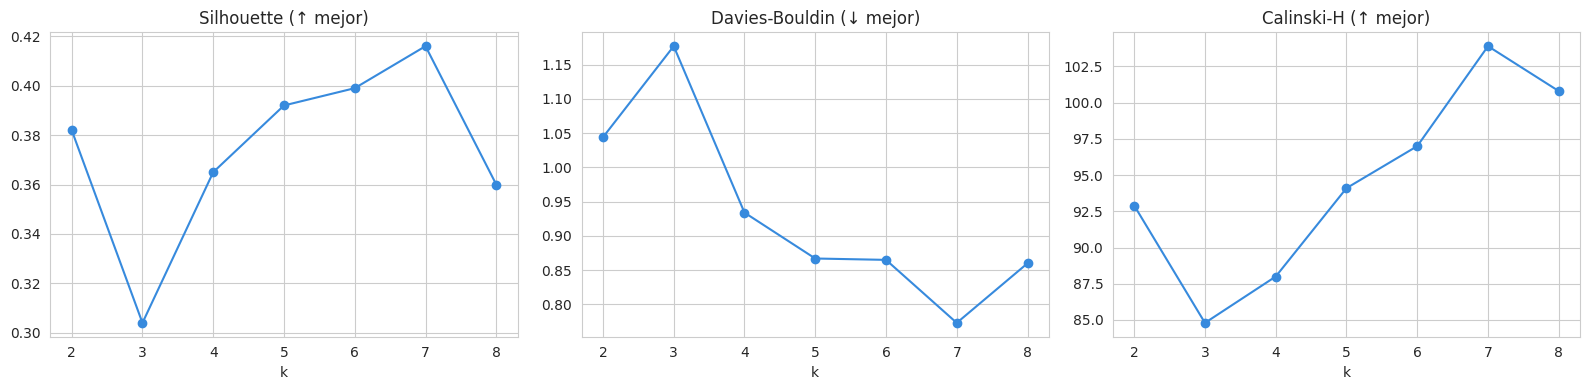

In [20]:
# Perfil de comportamiento a nivel de probeta
perfil = (dc.groupby(['ID_Probeta','Geometría','Material','Nº capas'])
            .agg(media=('Desviacion_pct','mean'),
                 desv=('Desviacion_pct','std'),
                 rango=('Desviacion_pct', lambda s: s.max()-s.min()),
                 nominal=('Espesor nominal','first'))
            .reset_index().dropna())
print(f'Probetas caracterizadas: {len(perfil)}')

Xc = StandardScaler().fit_transform(perfil[['media','desv','rango','nominal']])

res = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=50).fit_predict(Xc)
    res.append({'k': k,
                'Silhouette': round(silhouette_score(Xc, km), 3),
                'Davies-Bouldin': round(davies_bouldin_score(Xc, km), 3),
                'Calinski-H': round(calinski_harabasz_score(Xc, km), 1)})
met = pd.DataFrame(res)
print()
print('== MÉTRICAS INTERNAS DE CLUSTERING ==')
print(met.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (m, txt) in zip(axes, [('Silhouette','↑ mejor'),
                               ('Davies-Bouldin','↓ mejor'),
                               ('Calinski-H','↑ mejor')]):
    ax.plot(met['k'], met[m], 'o-', color=PAL[0])
    ax.set_title(f'{m} ({txt})'); ax.set_xlabel('k')
plt.tight_layout(); plt.show()

In [24]:
# Caracterización de las soluciones k=2 y k=4
for k in [2, 4]:
    perfil[f'C{k}'] = KMeans(n_clusters=k, random_state=SEED, n_init=50).fit_predict(Xc)
    print(f'=== k={k}: PERFILES MEDIOS ===')
    print(perfil.groupby(f'C{k}')[['media','desv','rango','nominal']].mean().round(2).to_string())
    print()
    print(pd.crosstab(perfil[f'C{k}'], perfil['Geometría']).to_string())
    print()
    print(pd.crosstab(perfil[f'C{k}'], perfil['Material']).to_string())
    print()

=== k=2: PERFILES MEDIOS ===
    media  desv  rango  nominal
C2                             
0    6.13  4.78  20.54     1.38
1    2.97  2.14   8.70     3.65

Geometría  Plana  R13 hembra  R15 hembra  R2 macho  R5 macho
C2                                                          
0             26           5           0         7         2
1             44          29          12         5        12

Material  PW Fabric  UD Tape
C2                          
0                21       19
1                42       60

=== k=4: PERFILES MEDIOS ===
    media  desv  rango  nominal
C4                             
0    7.17  2.79  11.28     2.58
1    0.71  1.99   8.45     2.81
2    2.15  1.93   7.19     7.49
3    5.87  5.35  23.03     1.35

Geometría  Plana  R13 hembra  R15 hembra  R2 macho  R5 macho
C4                                                          
0             33           8           0         2         0
1              8          19          12         5        10
2             

**Análisis: ausencia de estructura latente más allá de las variables de diseño**

Las métricas internas no muestran un número natural de grupos. El Silhouette es bajo en
todo el rango explorado (0,30-0,42) y **crece de forma monótona con k**, lo que es el patrón
característico de datos **sin estructura de clústeres real**: cada nuevo grupo mejora
marginalmente la métrica simplemente porque subdivide una nube continua.

Se decide caracterizar k=2 y k=4:

* k=2 por ser la partición más equilibrada con una silueta prácticamente igual a la del máximo y con lectura física directa: 40 unidades de desviación alta y dispersa frente a 102 de comportamiento contenido. Es decir, separa laminados finos e inestables de gruesos y estables.

* k=4 es la partición más fina que sigue siendo interpretable, con todos los grupos por encima de 17 unidades, y donde emerge un grupo que aísla limpiamente los laminados de 52 capas.

* Se descarta caracterizar k=7 pese a maximizar las tres métricas, ya que dos de sus siete grupos tienen 5 y 4 unidades sobre 142, y se definen por rangos extremos de 29 y 32 puntos porcentuales. El máximo de la silueta en k=7 no indica que existan siete grupos, sino que las métricas mejoran al subdividir una nube continua.

La caracterización de las soluciones confirma esta lectura. Con k=4, los grupos que emergen
se explican íntegramente por variables que ya conocíamos:

* **C0** (media +7,17 %, nominal 2,58 mm): dominado por probetas planas (33 de 43).
* **C1** (media +0,71 %, dispersión baja): agrupa las geometrías con radio hembra y R5
  (19 de R13, 12 de R15, 10 de R5), es decir, las configuraciones bien centradas.
* **C2** (nominal 7,49 mm): aísla exclusivamente los laminados de 52 capas de UD Tape.
* **C3** (media +5,87 %, rango 23,03): laminados finos (nominal 1,35 mm) y de alta
  variabilidad.

Es decir, el clustering reproduce esencialmente una segmentación por **geometría y espesor
del laminado**, que son precisamente dos de las variables de diseño que ya se incorporan al
modelo supervisado.

Este resultado, aunque negativo, tiene valor metodológico: **no existen agrupaciones ocultas
de comportamiento que las variables de diseño no capturen ya**. Esto refuerza la validez del
conjunto de características elegido para la fase supervisada y descarta la necesidad de introducir variables latentes
o de segmentar el modelado por familias de probetas.

## 4.4. Justificación del descarte de la reducción de dimensionalidad

Es habitual incluir PCA en los bloques de aprendizaje no supervisado. En este caso se
descarta de forma deliberada, y conviene razonar el motivo en lugar de aplicarlo por
inercia:

1. **El espacio de características no es de alta dimensión.** Se manejan nueve variables
   predictoras, de las cuales seis son categóricas. La reducción de dimensionalidad resuelve
   un problema (la maldición de la dimensionalidad) que aquí no se presenta.
2. **Destruiría la interpretabilidad, que es el principal valor del trabajo.** Una
   componente principal que mezcle «espesor nominal», «geometría R13» y «zona radio» no
   admite lectura física alguna. La finalidad del modelo no es solo predecir, sino
   identificar qué variables de fabricación gobiernan la desviación, y esa información se
   perdería.
3. **PCA sobre variables mayoritariamente categóricas codificadas one-hot es
   estadísticamente cuestionable**, ya que la varianza de una variable ficticia binaria no
   tiene la misma interpretación que la de una variable continua.

Sí se ha empleado, en cambio, una técnica conceptualmente próxima y mucho más informativa:
el análisis del **dataset traspuesto** de la sección 4.2, que aprovecha la estructura
espacial de las mediciones para contrastar una hipótesis concreta en lugar de comprimir el
espacio de forma ciega.

---
# 5 - PARTE II: APRENDIZAJE SUPERVISADO
---

## 5.1. Demostración de la fuga de información

Antes de comparar algoritmos se cuantifica el efecto de incluir `Espesor curado` entre
los predictores.

In [25]:
y_all = dc['Desviacion_pct']; g_all = dc['ID_Probeta']

# (a) CON el espesor curado entre las features: fuga de información
num_leak = ['Espesor curado', 'Espesor nominal', 'Nº capas', 'Es_radio']
cat_leak = ['Material', 'Geometría', 'Zona', 'FV']
r_leak = evaluar(RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1),
                 dc[num_leak+cat_leak], y_all, g_all, num_leak, cat_leak)

# (b) SIN el espesor curado: planteamiento correcto
num_ok = ['Espesor nominal', 'Nº capas', 'Es_radio']
cat_ok = ['Material', 'Geometría', 'Zona', 'FV']
r_ok = evaluar(RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1),
               dc[num_ok+cat_ok], y_all, g_all, num_ok, cat_ok)

print('== EFECTO DE LA FUGA DE INFORMACIÓN ==')
print(f"CON 'Espesor curado'  ->  R2 = {r_leak['R2']:.4f}   MAE = {r_leak['MAE']:.3f} %")
print(f"SIN 'Espesor curado'  ->  R2 = {r_ok['R2']:.4f}   MAE = {r_ok['MAE']:.3f} %")
print()
print(f"Sobreestimación del R2: {r_leak['R2']-r_ok['R2']:+.4f}")
print(f"Infraestimación del MAE: {r_leak['MAE']-r_ok['MAE']:+.3f} puntos porcentuales")

== EFECTO DE LA FUGA DE INFORMACIÓN ==
CON 'Espesor curado'  ->  R2 = 0.8474   MAE = 0.639 %
SIN 'Espesor curado'  ->  R2 = 0.3132   MAE = 2.829 %

Sobreestimación del R2: +0.5342
Infraestimación del MAE: -2.191 puntos porcentuales


**Análisis del efecto de la fuga**

Incluir `Espesor curado` eleva el R² de **0,31 a 0,85** y reduce el MAE de 2,83 a 0,64
puntos porcentuales. Ese rendimiento es enteramente artificial: el modelo no está aprendiendo
ninguna relación física, sino **reconstruyendo el target a partir de su propia definición**,
puesto que el target es exactamente el cociente entre esa variable y el espesor nominal, que
también se le proporciona.

Que el R² no alcance 1,00 se explica porque un ensemble de árboles aproxima mal una división
exacta; un modelo capaz de representar cocientes lo reproduciría casi perfectamente. El
argumento no cambia: **el resultado carece de contenido**.

En consecuencia, todos los modelos posteriores emplean exclusivamente variables conocidas
antes de medir la pieza. La pregunta que se responde es *«dada una configuración de
fabricación, ¿cuánto se desviará el espesor?»*, no *«dado el espesor medido, cuál es su
desviación?»*.

## 5.2. Validación agrupada por probeta frente a validación aleatoria

In [26]:
num, cat = SETS['A2 diseño completo']
X = dc[num + cat]

pipe_rf = Pipeline([('prep', make_prep(num, cat)),
                    ('mod', RandomForestRegressor(n_estimators=300,
                                                  random_state=SEED, n_jobs=-1))])

r_rand = cross_val_score(pipe_rf, X, y_all, scoring='r2',
                         cv=KFold(5, shuffle=True, random_state=SEED))
r_grp  = cross_val_score(pipe_rf, X, y_all, scoring='r2',
                         cv=GroupKFold(5), groups=g_all)

print('== COMPARACIÓN DE ESQUEMAS DE VALIDACIÓN ==')
print(f"KFold aleatorio     : R2 = {r_rand.mean():.4f}  (+/- {r_rand.std():.4f})")
print(f"GroupKFold (probeta): R2 = {r_grp.mean():.4f}  (+/- {r_grp.std():.4f})")
print()
print(f"Sobreestimación por no agrupar: {r_rand.mean()-r_grp.mean():+.4f} de R2")
print(f"Aumento de la varianza entre folds: {r_grp.std()/r_rand.std():.1f}x")

== COMPARACIÓN DE ESQUEMAS DE VALIDACIÓN ==
KFold aleatorio     : R2 = 0.3647  (+/- 0.0313)
GroupKFold (probeta): R2 = 0.3474  (+/- 0.1026)

Sobreestimación por no agrupar: +0.0173 de R2
Aumento de la varianza entre folds: 3.3x


**Análisis de los esquemas de validación**

La validación aleatoria arroja un R² de 0,3647 frente a 0,3472 con agrupación por probeta.
La sobreestimación (+0,0175) es más moderada de lo que cabría esperar, y merece
interpretarse con precisión en lugar de exagerarse: ocurre porque las variables predictoras
son mayoritariamente categóricas y de diseño, de modo que los puntos de una misma probeta
comparten casi todos sus valores de entrada y aportan poca información adicional al
memorizarse.

El efecto verdaderamente relevante está en la **variabilidad entre particiones**: la
desviación típica del R² pasa de 0,031 a 0,103, más del triple. Esto es lo esperable y lo
honesto: con sólo 92 probetas, la partición agrupada deja fuera bloques enteros de piezas y
el rendimiento fluctúa según qué configuraciones caigan en test. La validación aleatoria
oculta esa incertidumbre y transmite una falsa sensación de estabilidad.

Se adopta por tanto **GroupKFold por probeta en todo el trabajo**. La conclusión práctica es
que las métricas deben leerse siempre con su desviación entre folds, no como valores
puntuales.

## 5.3. Comparación de conjuntos de características

In [27]:
filas = []
for nom, (num, cat) in SETS.items():
    r = evaluar(RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1),
                dc[num+cat], y_all, g_all, num, cat)
    filas.append({'Conjunto': nom, 'nº variables': len(num)+len(cat),
                  'MAE': round(r['MAE'],3), 'RMSE': round(r['RMSE'],3),
                  'R2': round(r['R2'],4), 'R2 sd': round(r['R2_sd'],3)})
print('== COMPARATIVA DE CONJUNTOS DE CARACTERÍSTICAS (Random Forest fijo) ==')
print(pd.DataFrame(filas).to_string(index=False))

== COMPARATIVA DE CONJUNTOS DE CARACTERÍSTICAS (Random Forest fijo) ==
          Conjunto  nº variables   MAE  RMSE     R2  R2 sd
  A1 diseño mínimo             5 2.807 4.043 0.3225  0.127
A2 diseño completo             9 2.722 3.971 0.3474  0.103
B diseño + proceso            11 2.626 4.032 0.3028  0.240


**Análisis de los conjuntos de características**

| Conjunto | MAE | R² | R² sd |
|---|---|---|---|
| A1 diseño mínimo | 2,807 | 0,3226 | 0,127 |
| A2 diseño completo | 2,722 | 0,3472 | 0,103 |
| B diseño + proceso | 2,626 | 0,3033 | 0,240 |

El conjunto **A2** resulta el más equilibrado: mejora A1 tanto en MAE como en R², e incluso
reduce la variabilidad entre particiones. La incorporación del punto y la sección de
medición aporta información real, coherente con el efecto de posición detectado.

El caso de **B** es más interesante y confirma la sospecha planteada en la sección 3. Añadir
el perfil y el lote de curado **mejora el MAE (2,626, el mejor de los tres) pero empeora el
R² (0,3033) y casi duplica su desviación entre folds (0,240)**. Esta combinación aparentemente
contradictoria tiene una explicación clara: al estar cada lote anidado en una única
geometría, el modelo memoriza la media de cada lote, lo que reduce el error típico en los
folds donde ese lote está representado en entrenamiento, pero produce fallos grandes cuando
la partición aísla lotes completos. El resultado es un modelo **más preciso en promedio y
mucho menos fiable**.

Dado que el objetivo del TFM es obtener un modelo generalizable y no minimizar una métrica,
**se adopta A2 como conjunto de referencia**. El conjunto B se conserva como evidencia
cuantificada de la existencia de un efecto de lote de curado, que se recoge como limitación
y como línea futura.

## 5.4. Comparativa de algoritmos con optimización de hiperparámetros

Se comparan nueve modelos, siguiendo una progresión de complejidad creciente en la que
cada familia aporta algo que la anterior no tiene:

1. **Baseline (media)**: referencia mínima. Cualquier modelo debe superarla.
2. **Regresión lineal y Ridge**: relaciones aditivas; Ridge añade regularización.
3. **Árbol de decisión**: rompe la linealidad al coste conceptual mínimo.
4. **Random Forest**: reduce la varianza del árbol mediante agregación.
5. **Gradient Boosting y XGBoost**: construcción secuencial con corrección de residuos.
6. **SVR (RBF)**: pérdida épsilon-insensible, robusta frente a valores extremos.
7. **k-NN**: predicción por similitud directa, sin modelo explícito.

Para cada modelo se aplica el esquema en dos fases **`RandomizedSearchCV` →
`GridSearchCV`**: exploración amplia y aleatoria del espacio de hiperparámetros, seguida de
refinamiento en una cuadrícula estrecha en torno al óptimo encontrado. La búsqueda se realiza
con `GroupKFold(3)` para contener el coste computacional, y la evaluación final con
`GroupKFold(5)`.

In [28]:
def buscar(nombre, model, dist, grid_fn, scale=False, n_iter=25, n_splits_search=3):
    """RandomizedSearchCV -> GridSearchCV, siempre agrupando por probeta."""
    cv_s = GroupKFold(n_splits=n_splits_search)
    pipe = Pipeline([('prep', make_prep(num, cat, scale)), ('mod', model)])

    rnd = RandomizedSearchCV(pipe, {f'mod__{k}': v for k, v in dist.items()},
                             n_iter=n_iter, cv=cv_s, n_jobs=-1,
                             scoring='neg_mean_absolute_error', random_state=SEED)
    rnd.fit(X, y_all, groups=g_all)
    bp = {k.replace('mod__',''): v for k, v in rnd.best_params_.items()}
    print(f'[{nombre}] RandomizedSearch  MAE={-rnd.best_score_:.3f}')
    print(f'           {bp}')

    gs = GridSearchCV(pipe, {f'mod__{k}': v for k, v in grid_fn(bp).items()},
                      cv=cv_s, n_jobs=-1, scoring='neg_mean_absolute_error')
    gs.fit(X, y_all, groups=g_all)
    bp2 = {k.replace('mod__',''): v for k, v in gs.best_params_.items()}
    print(f'[{nombre}] GridSearch        MAE={-gs.best_score_:.3f}')
    print(f'           {bp2}')
    return bp2

num, cat = SETS['A2 diseño completo']
X = dc[num + cat]
resultados = {}
print('Función de búsqueda definida. Conjunto de trabajo: A2')

Función de búsqueda definida. Conjunto de trabajo: A2


In [29]:
# --- Baseline y modelos lineales ---
resultados['Baseline (media)'] = evaluar(DummyRegressor(strategy='mean'),
                                         X, y_all, g_all, num, cat)
resultados['Regresión lineal'] = evaluar(LinearRegression(), X, y_all, g_all, num, cat)

p_ridge = buscar('Ridge', Ridge(random_state=SEED),
                 {'alpha': [0.01, 0.1, 1, 5, 10, 50, 100, 500]},
                 lambda b: {'alpha': sorted({round(max(1e-3, b['alpha']*f), 4)
                                             for f in (0.5, 1, 2)})},
                 scale=True, n_iter=8)
resultados['Ridge'] = evaluar(Ridge(**p_ridge, random_state=SEED),
                              X, y_all, g_all, num, cat, scale=True)

[Ridge] RandomizedSearch  MAE=2.780
           {'alpha': 10}
[Ridge] GridSearch        MAE=2.778
           {'alpha': 20}


In [30]:
# --- Árbol de decisión ---
p_dt = buscar('Árbol de decisión', DecisionTreeRegressor(random_state=SEED),
              {'max_depth': [None, 4, 6, 8, 12, 16],
               'min_samples_leaf': sp_randint(2, 60),
               'min_samples_split': sp_randint(2, 40),
               'ccp_alpha': [0.0, 0.001, 0.01, 0.1]},
              lambda b: {'max_depth': [b['max_depth']],
                         'min_samples_leaf': sorted({max(1, b['min_samples_leaf']+o)
                                                     for o in (-3, 0, 3)}),
                         'min_samples_split': sorted({max(2, b['min_samples_split']+o)
                                                      for o in (-3, 0, 3)}),
                         'ccp_alpha': [b['ccp_alpha']]}, n_iter=20)
resultados['Árbol de decisión'] = evaluar(DecisionTreeRegressor(**p_dt, random_state=SEED),
                                          X, y_all, g_all, num, cat)

[Árbol de decisión] RandomizedSearch  MAE=2.752
           {'ccp_alpha': 0.001, 'max_depth': 16, 'min_samples_leaf': 7, 'min_samples_split': 5}
[Árbol de decisión] GridSearch        MAE=2.735
           {'ccp_alpha': 0.001, 'max_depth': 16, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [31]:
# --- Random Forest ---
p_rf = buscar('Random Forest', RandomForestRegressor(random_state=SEED, n_jobs=2),
              {'n_estimators': [200, 300], 'max_depth': [None, 6, 10, 15, 20],
               'min_samples_leaf': sp_randint(1, 40),
               'min_samples_split': sp_randint(2, 30),
               'max_features': ['sqrt', 'log2', 0.5, 1.0]},
              lambda b: {'n_estimators': [b['n_estimators']],
                         'max_depth': [b['max_depth']],
                         'min_samples_leaf': sorted({max(1, b['min_samples_leaf']+o)
                                                     for o in (-3, 0, 3)}),
                         'min_samples_split': sorted({max(2, b['min_samples_split']+o)
                                                      for o in (-3, 0, 3)}),
                         'max_features': [b['max_features']]}, n_iter=15)
resultados['Random Forest'] = evaluar(RandomForestRegressor(**p_rf, random_state=SEED,
                                                            n_jobs=-1),
                                      X, y_all, g_all, num, cat)

[Random Forest] RandomizedSearch  MAE=2.578
           {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 21, 'n_estimators': 300}
[Random Forest] GridSearch        MAE=2.574
           {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 18, 'n_estimators': 300}


In [32]:
# --- Gradient Boosting ---
p_gb = buscar('Gradient Boosting', GradientBoostingRegressor(random_state=SEED),
              {'n_estimators': [100, 200, 300], 'learning_rate': [0.01, 0.03, 0.05, 0.1],
               'max_depth': sp_randint(2, 7), 'min_samples_leaf': sp_randint(5, 60),
               'subsample': sp_uniform(0.6, 0.4)},
              lambda b: {'n_estimators': sorted({max(50, int(b['n_estimators']*f))
                                                 for f in (0.7, 1, 1.4)}),
                         'learning_rate': [b['learning_rate']],
                         'max_depth': sorted({max(2, b['max_depth']+o) for o in (-1, 0, 1)}),
                         'min_samples_leaf': sorted({max(2, b['min_samples_leaf']+o)
                                                     for o in (-5, 0, 5)}),
                         'subsample': [round(b['subsample'], 3)]}, n_iter=20)
resultados['Gradient Boosting'] = evaluar(GradientBoostingRegressor(**p_gb,
                                                                    random_state=SEED),
                                          X, y_all, g_all, num, cat)

[Gradient Boosting] RandomizedSearch  MAE=2.594
           {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 6, 'n_estimators': 200, 'subsample': np.float64(0.8080272084711243)}
[Gradient Boosting] GridSearch        MAE=2.588
           {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 2, 'n_estimators': 200, 'subsample': np.float64(0.808)}


In [33]:
# --- XGBoost ---
p_xgb = buscar('XGBoost', xgb.XGBRegressor(random_state=SEED, verbosity=0),
               {'n_estimators': [100, 200, 300, 500],
                'learning_rate': [0.01, 0.03, 0.05, 0.1],
                'max_depth': sp_randint(2, 8), 'subsample': sp_uniform(0.6, 0.4),
                'colsample_bytree': sp_uniform(0.6, 0.4),
                'reg_lambda': [0.1, 1, 5, 10], 'min_child_weight': sp_randint(1, 20)},
               lambda b: {'n_estimators': sorted({max(50, int(b['n_estimators']*f))
                                                  for f in (0.7, 1, 1.4)}),
                          'learning_rate': [b['learning_rate']],
                          'max_depth': sorted({max(2, b['max_depth']+o) for o in (-1, 0, 1)}),
                          'subsample': [round(b['subsample'], 3)],
                          'colsample_bytree': [round(b['colsample_bytree'], 3)],
                          'reg_lambda': [b['reg_lambda']],
                          'min_child_weight': sorted({max(1, b['min_child_weight']+o)
                                                      for o in (-3, 0, 3)})})
resultados['XGBoost'] = evaluar(xgb.XGBRegressor(**p_xgb, random_state=SEED, verbosity=0),
                                X, y_all, g_all, num, cat)

[XGBoost] RandomizedSearch  MAE=2.586
           {'colsample_bytree': np.float64(0.662397808134481), 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 4, 'n_estimators': 500, 'reg_lambda': 10, 'subsample': np.float64(0.8603553891795411)}
[XGBoost] GridSearch        MAE=2.586
           {'colsample_bytree': np.float64(0.662), 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 4, 'n_estimators': 700, 'reg_lambda': 10, 'subsample': np.float64(0.86)}


In [34]:
# --- SVR y k-NN (requieren escalado) ---
p_svr = buscar('SVR (RBF)', SVR(cache_size=700),
               {'kernel': ['rbf'], 'C': [1, 5, 10, 25, 50, 100],
                'epsilon': [0.1, 0.3, 0.5, 0.8, 1.2],
                'gamma': ['scale', 0.01, 0.05, 0.1]},
               lambda b: {'kernel': [b['kernel']],
                          'C': sorted({max(0.5, b['C']*f) for f in (0.5, 1, 2)}),
                          'epsilon': sorted({round(max(0.05, b['epsilon']*f), 3)
                                             for f in (0.7, 1, 1.3)}),
                          'gamma': [b['gamma']]}, scale=True, n_iter=12)
resultados['SVR (RBF)'] = evaluar(SVR(**p_svr, cache_size=700),
                                  X, y_all, g_all, num, cat, scale=True)

p_knn = buscar('k-NN', KNeighborsRegressor(),
               {'n_neighbors': sp_randint(3, 60), 'weights': ['uniform', 'distance'],
                'metric': ['euclidean', 'manhattan']},
               lambda b: {'n_neighbors': sorted({max(2, b['n_neighbors']+o)
                                                 for o in (-4, -2, 0, 2, 4)}),
                          'weights': [b['weights']], 'metric': [b['metric']]},
               scale=True, n_iter=20)
resultados['k-NN'] = evaluar(KNeighborsRegressor(**p_knn),
                             X, y_all, g_all, num, cat, scale=True)

[SVR (RBF)] RandomizedSearch  MAE=2.535
           {'kernel': 'rbf', 'gamma': 0.1, 'epsilon': 0.8, 'C': 10}
[SVR (RBF)] GridSearch        MAE=2.521
           {'C': 5.0, 'epsilon': 0.56, 'gamma': 0.1, 'kernel': 'rbf'}
[k-NN] RandomizedSearch  MAE=2.700
           {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'uniform'}
[k-NN] GridSearch        MAE=2.700
           {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'uniform'}


## 5.5. Tabla comparativa de modelos

== TABLA COMPARATIVA FINAL (GroupKFold=5 por probeta) ==
                      MAE  MAE_sd    RMSE      R2   R2_sd
SVR (RBF)          2.4812  0.2691  3.7063  0.4325  0.0983
Random Forest      2.5523  0.2857  3.7374  0.4215  0.1065
XGBoost            2.5877  0.2811  3.7999  0.4013  0.1049
Gradient Boosting  2.5963  0.2824  3.7942  0.4032  0.1073
k-NN               2.6483  0.2871  3.8259  0.3951  0.0947
Ridge              2.7412  0.1919  3.8633  0.3811  0.0922
Regresión lineal   2.7473  0.1806  3.8706  0.3786  0.0885
Árbol de decisión  2.7861  0.3394  3.9988  0.3376  0.1103
Baseline (media)   3.8575  0.2461  4.9446 -0.0060  0.0075


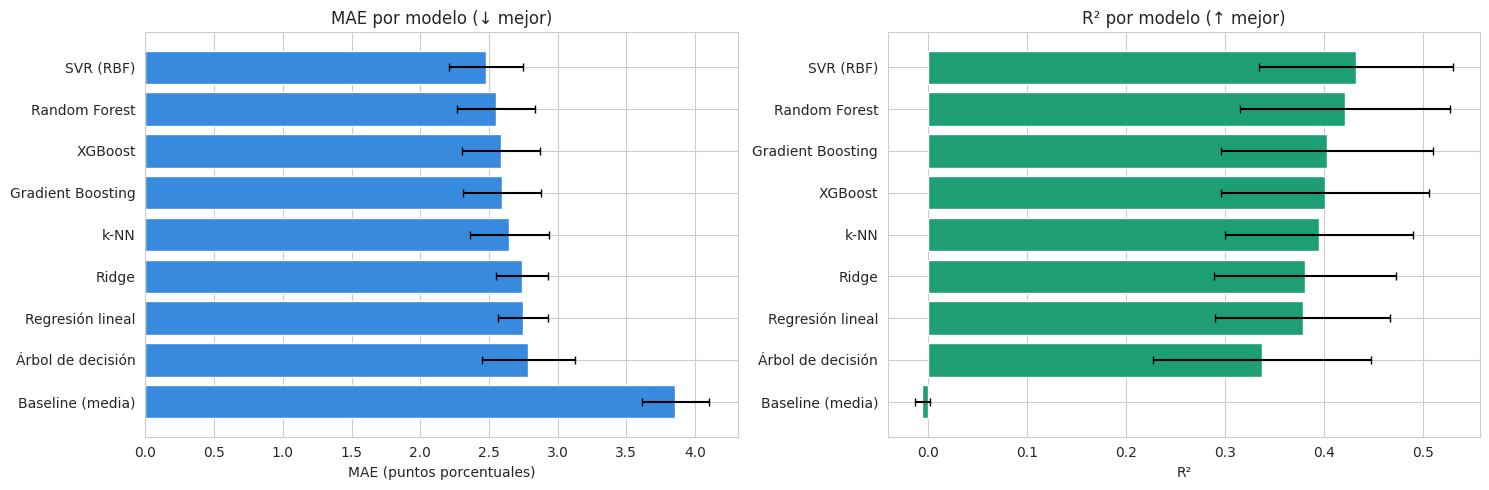

In [35]:
tabla = pd.DataFrame(resultados).T.round(4).sort_values('MAE')
print('== TABLA COMPARATIVA FINAL (GroupKFold=5 por probeta) ==')
print(tabla.to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
t = tabla.sort_values('MAE')
axes[0].barh(t.index, t['MAE'], xerr=t['MAE_sd'], color=PAL[0], edgecolor='white', capsize=3)
axes[0].set_xlabel('MAE (puntos porcentuales)'); axes[0].set_title('MAE por modelo (↓ mejor)')
axes[0].invert_yaxis()

t2 = tabla.sort_values('R2', ascending=False)
axes[1].barh(t2.index, t2['R2'], xerr=t2['R2_sd'], color=PAL[2], edgecolor='white', capsize=3)
axes[1].set_xlabel('R²'); axes[1].set_title('R² por modelo (↑ mejor)')
axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

**Análisis de la comparativa de modelos**

| Modelo | MAE | MAE sd | RMSE | R² | R² sd |
|---|---|---|---|---|---|
| SVR (RBF) | 2,481 | 0,269 | 3,706 | **0,4325** | 0,098 |
| Random Forest | 2,553 | 0,286 | 3,737 | 0,4215 | 0,107 |
| XGBoost | 2,588 | 0,281 | 3,800 | 0,4013 | 0,105 |
| Gradient Boosting | 2,598 | 0,282 | 3,796 | 0,4029 | 0,107 |
| k-NN | 2,648 | 0,287 | 3,826 | 0,3951 | 0,095 |
| Ridge | 2,741 | 0,192 | 3,863 | 0,3811 | 0,092 |
| Regresión lineal | 2,747 | 0,181 | 3,871 | 0,3786 | 0,088 |
| Árbol de decisión | 2,786 | 0,339 | 3,999 | 0,3376 | 0,110 |
| Baseline (media) | 3,857 | 0,246 | 4,945 | −0,006 | 0,007 |

Se extraen cinco conclusiones:

**1. Todos los modelos superan claramente al baseline.** La media global obtiene un R² de
−0,006 (equivalente a no explicar nada) y un MAE de 3,857. El mejor modelo reduce el error
un 36 %, lo que confirma que **las variables de diseño contienen señal real** sobre la
desviación de espesor.

**2. SVR (RBF) es el mejor modelo**, con MAE = 2,481 y R² = 0,4325. Su ventaja es coherente
con la naturaleza del problema: la pérdida épsilon-insensible ignora los errores pequeños y no penaliza cuadráticamente los valores
extremos que se han conservado deliberadamente.

**3. Los métodos de ensemble quedan muy próximos entre sí** (Random Forest 0,4215; Gradient
Boosting 0,4029; XGBoost 0,4013), sin que el boosting aporte ventaja sobre el bagging. Esto
es indicativo de que **la relación a modelar no es especialmente compleja**: se trata
básicamente de desplazamientos de nivel por geometría, zona y espesor, que un promedio de
árboles captura tan bien como una construcción secuencial.

**4. La regresión lineal es notablemente competitiva** (R² = 0,3786 frente a 0,4325 del
mejor modelo), y además es **el modelo más estable** de todos (R² sd = 0,088, la menor de la
tabla). La ganancia total por pasar de un modelo lineal a uno no lineal es de apenas 0,05
de R². Este es un argumento sólido a favor de reportar el modelo lineal como referencia
interpretable en la memoria del TFM.

**5. El techo de rendimiento está en torno a R² ≈ 0,43**, y es un resultado que debe
presentarse como tal, sin adornos. Significa que las variables de diseño explican
aproximadamente el 43 % de la varianza de la desviación de espesor, y que **el 57 %
restante corresponde a variabilidad no capturada** por material, geometría, espesor y
posición: variabilidad de proceso, del moldeo manual, del operario y de la propia medición.
La sección 7 profundiza en la naturaleza de ese residuo.

---
# 6. Interpretabilidad
---

La interpretabilidad es la vía por la que el modelo se traduce en
conocimiento útil para el proceso de fabricación. Se emplean tres enfoques complementarios,
sobre el modelo Random Forest optimizado (se prefiere a SVR por ser un modelo de árboles,
compatible con `TreeExplainer` de SHAP y con importancia nativa, a un coste mínimo en
rendimiento):

1. **Importancia nativa**, rápida pero sesgada hacia variables de alta cardinalidad.
2. **Importancia por permutación** sobre las variables originales, que evita el sesgo de la
   codificación one-hot al permutar la columna completa antes de codificar.
3. **SHAP**, que descompone cada predicción individual en contribuciones por variable.

In [36]:
p_rf_final = p_rf if 'p_rf' in dir() else {'n_estimators':300,'max_depth':None,
                                            'min_samples_leaf':1,'min_samples_split':18,
                                            'max_features':'log2'}
pipe_int = Pipeline([('prep', make_prep(num, cat)),
                     ('mod', RandomForestRegressor(**p_rf_final, random_state=SEED,
                                                   n_jobs=-1))])
pipe_int.fit(X, y_all)

names = [n.split('__', 1)[1] for n in pipe_int.named_steps['prep'].get_feature_names_out()]
imp = pd.Series(pipe_int.named_steps['mod'].feature_importances_, index=names)

def grupo(n):
    for v in cat:
        if n.startswith(v + '_'):
            return v
    return n

print('== IMPORTANCIA NATIVA — TOP 15 (%) ==')
print((imp.sort_values(ascending=False).head(15)*100).round(2).to_string())
print()
print('== IMPORTANCIA NATIVA AGREGADA POR VARIABLE ORIGINAL (%) ==')
print((imp.groupby(grupo).sum().sort_values(ascending=False)*100).round(2).to_string())

== IMPORTANCIA NATIVA — TOP 15 (%) ==
Geometría_Plana         15.57
Seccion_f_NA            15.17
Espesor nominal          7.67
Nº capas                 6.44
Geometría_R5 macho       3.92
Zona_Faldilla            3.63
Zona_Alma                3.31
FV_NO                    3.04
FV_SI                    2.76
Geometría_R15 hembra     2.02
Geometría_R13 hembra     1.84
Geometría_R2 macho       1.65
Material_PW Fabric       1.46
Material_UD Tape         1.40
Punto_geo_Pla_P12        1.22

== IMPORTANCIA NATIVA AGREGADA POR VARIABLE ORIGINAL (%) ==
Geometría          24.98
Punto_geo          22.75
Seccion_f          20.57
Zona                7.87
Espesor nominal     7.67
Nº capas            6.44
FV                  5.80
Material            2.86
Es_radio            1.05


== IMPORTANCIA POR PERMUTACIÓN (incremento del MAE al permutar) ==
       Variable  Delta MAE    sd
      Geometría      0.622 0.017
      Seccion_f      0.369 0.010
      Punto_geo      0.336 0.007
Espesor nominal      0.221 0.009
       Material      0.189 0.006
             FV      0.162 0.004
           Zona      0.148 0.010
       Nº capas      0.147 0.006
       Es_radio      0.026 0.002


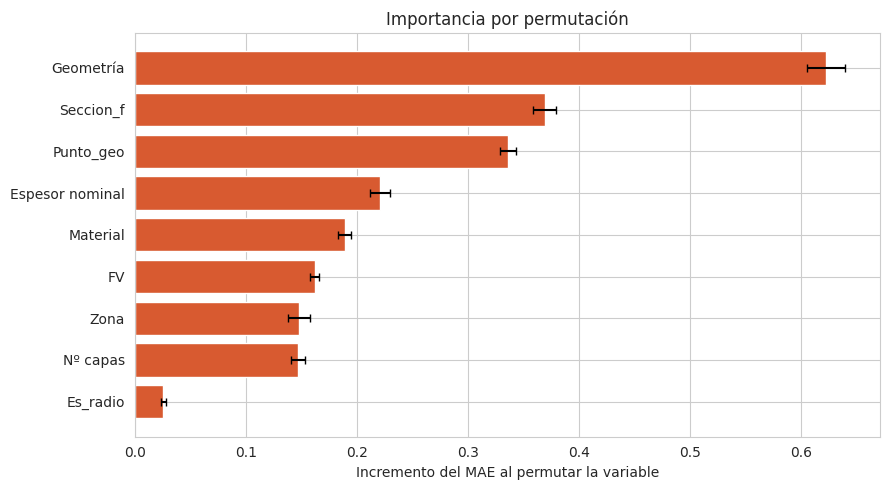

In [37]:
# Importancia por permutación sobre las variables ORIGINALES (antes de one-hot)
base = mean_absolute_error(y_all, pipe_int.predict(X))
rng = np.random.default_rng(SEED)
rows = []
for col in num + cat:
    inc = []
    for _ in range(5):
        Xp = X.copy()
        Xp[col] = rng.permutation(Xp[col].values)
        inc.append(mean_absolute_error(y_all, pipe_int.predict(Xp)) - base)
    rows.append({'Variable': col, 'Delta MAE': round(float(np.mean(inc)), 3),
                 'sd': round(float(np.std(inc)), 3)})
pi = pd.DataFrame(rows).sort_values('Delta MAE', ascending=False)

print('== IMPORTANCIA POR PERMUTACIÓN (incremento del MAE al permutar) ==')
print(pi.to_string(index=False))

plt.figure(figsize=(9, 5))
plt.barh(pi['Variable'], pi['Delta MAE'], xerr=pi['sd'], color=PAL[1],
         edgecolor='white', capsize=3)
plt.gca().invert_yaxis()
plt.xlabel('Incremento del MAE al permutar la variable')
plt.title('Importancia por permutación')
plt.tight_layout(); plt.show()

== |SHAP| MEDIO — TOP 15 ==
Geometría_Plana         0.8097
Seccion_f_NA            0.7967
Espesor nominal         0.3647
Nº capas                0.2669
Zona_Faldilla           0.2642
Geometría_R5 macho      0.2579
Zona_Alma               0.1852
FV_NO                   0.1652
FV_SI                   0.1581
Geometría_R15 hembra    0.1289
Material_PW Fabric      0.1118
Material_UD Tape        0.1096
Geometría_R13 hembra    0.0958
Geometría_R2 macho      0.0955
Es_radio                0.0886

== |SHAP| AGREGADO POR VARIABLE ORIGINAL ==
Geometría          1.3878
Punto_geo          1.2377
Seccion_f          1.1109
Zona               0.5291
Espesor nominal    0.3647
FV                 0.3233
Nº capas           0.2669
Material           0.2214
Es_radio           0.0886


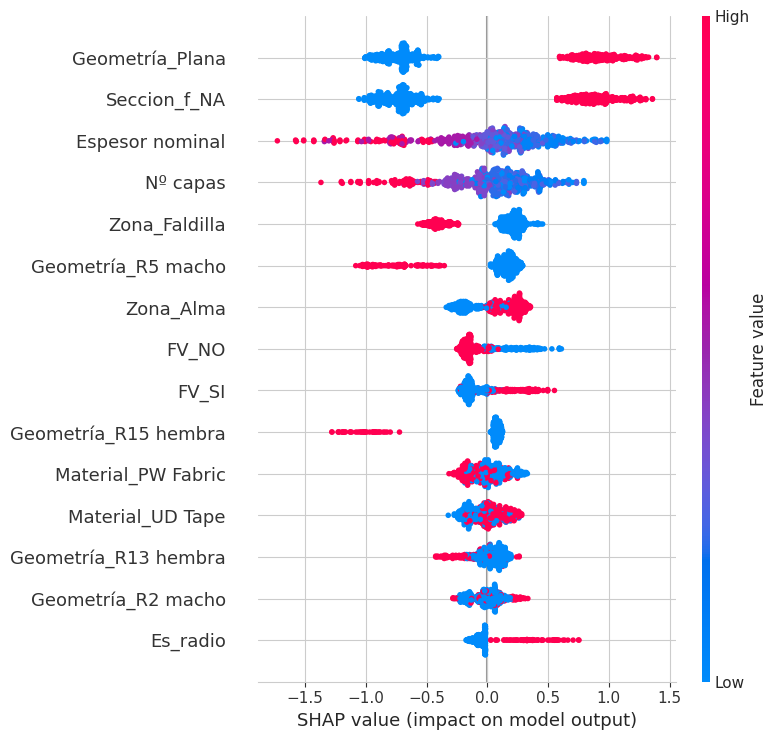

In [38]:
# SHAP sobre el Random Forest
Xt = pipe_int.named_steps['prep'].transform(X)
idx = np.random.default_rng(SEED).choice(len(Xt), 800, replace=False)
explainer = shap.TreeExplainer(pipe_int.named_steps['mod'])
sv = explainer.shap_values(Xt[idx], check_additivity=False)

msv = pd.Series(np.abs(sv).mean(axis=0), index=names).sort_values(ascending=False)
print('== |SHAP| MEDIO — TOP 15 ==')
print(msv.head(15).round(4).to_string())
print()
print('== |SHAP| AGREGADO POR VARIABLE ORIGINAL ==')
print(msv.groupby(grupo).sum().sort_values(ascending=False).round(4).to_string())

shap.summary_plot(sv, Xt[idx], feature_names=names, max_display=15, show=False)
plt.tight_layout(); plt.show()

**Análisis de la interpretabilidad**

Los tres enfoques coinciden en el orden de las variables principales, lo que refuerza la
fiabilidad de la lectura:

| Variable | Permutación (Δ MAE) | SHAP agregado |
|---|---|---|
| Geometría | 0,621 | 1,387 |
| Sección | 0,369 | 1,112 |
| Punto | 0,336 | 1,237 |
| Espesor nominal | 0,221 | 0,364 |
| Material | 0,189 | 0,222 |
| FV | 0,162 | 0,323 |
| Zona | 0,148 | 0,529 |
| Nº capas | 0,147 | 0,267 |
| Es_radio | 0,026 | 0,089 |

**1. La geometría es la variable dominante**, con un margen amplio sobre todas las demás.
Su permutación degrada el MAE en 0,621 puntos, casi el doque la siguiente. Esto es coherente
con la exploración: la desviación media va desde +6,77 % en planas hasta −0,48 % en R15, y
esa diferencia de nivel entre geometrías es la principal fuente de señal del modelo.

**2. La posición de medición (sección y punto) ocupa el segundo bloque de importancia**,
por delante del espesor nominal y del material. Este es un resultado con implicaciones
prácticas: **dónde se mide importa más que con qué material se fabrica**, lo que refuerza la
necesidad de protocolos de medición con posiciones fijas y trazables, y advierte de que
cualquier comparación entre piezas medidas en puntos distintos es engañosa.

**3. El material aparece en una posición intermedia y baja** (Δ MAE = 0,189). Debe insistirse
en que esta cifra **no es interpretable como efecto del material**, por la confusión
estructural con el número de capas documentada en el apartado 2.1. El modelo no puede, y por tanto
nosotros tampoco, atribuir esa importancia a la arquitectura del refuerzo frente al espesor
del laminado.

**4. `Es_radio` obtiene importancia muy baja (0,026)**. La
explicación es la redundancia: `Zona`, `Punto` y `Es_radio` codifican en gran medida la misma
información, y al permutar una de ellas el modelo la recupera de las otras dos. La
importancia por permutación mide la información *exclusiva* de cada variable, no su
relevancia física. El efecto radio está sólidamente establecido por el análisis no
supervisado y por las medias por punto; lo que este resultado indica es que **ya está
capturado por la variable `Punto`**, más granular.

**5. La presencia de fibra de vidrio (`FV`) tiene importancia apreciable** (0,162), superior
a la de `Zona` y `Nº capas`. Es un resultado a destacar, ya que sólo afecta a una fracción de
las probetas planas, y sugiere que la capa exterior de vidrio sí introduce un efecto medible
sobre la desviación relativa del espesor.

---
# 7. Análisis de errores
---

In [39]:
pred = cross_val_predict(pipe_int, X, y_all, cv=cv, groups=g_all)
dd = dc.copy()
dd['pred'] = pred
dd['err']  = dd['pred'] - dd['Desviacion_pct']

def desglose(col):
    return dd.groupby(col).apply(lambda t: pd.Series({
        'n': len(t),
        'MAE': np.abs(t['err']).mean(),
        'Sesgo': t['err'].mean(),
        'R2 interno': 1 - ((t['err']**2).sum() /
                           ((t['Desviacion_pct']-t['Desviacion_pct'].mean())**2).sum())
    })).round(3)

print('== DESGLOSE POR GEOMETRÍA ==')
print(desglose('Geometría').to_string())
print()
print('== DESGLOSE POR ZONA ==')
print(desglose('Zona').to_string())
print()
print('== DESGLOSE POR MATERIAL ==')
print(desglose('Material').to_string())

== DESGLOSE POR GEOMETRÍA ==
                 n    MAE  Sesgo  R2 interno
Geometría                                   
Plana       2235.0  3.188  0.074       0.157
R13 hembra   920.0  2.717 -0.087      -0.001
R15 hembra   288.0  1.659  0.143       0.038
R2 macho    1155.0  2.130 -0.054       0.234
R5 macho     840.0  1.571  0.130       0.170

== DESGLOSE POR ZONA ==
               n    MAE  Sesgo  R2 interno
Zona                                      
Alma      3534.0  2.739  0.037       0.396
Faldilla  1370.0  1.907  0.010       0.133
Radio      534.0  2.975  0.053       0.182

== DESGLOSE POR MATERIAL ==
                n    MAE  Sesgo  R2 interno
Material                                   
PW Fabric  2532.0  2.440  0.057       0.385
UD Tape    2906.0  2.651  0.010       0.447


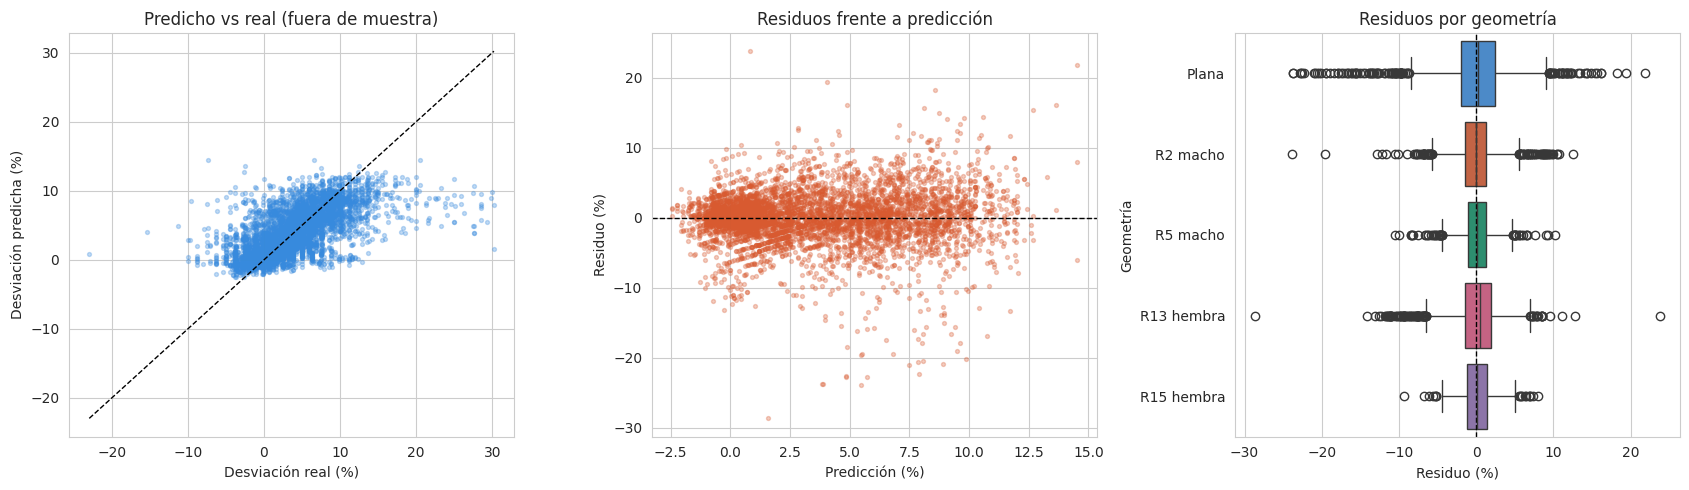

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].scatter(dd['Desviacion_pct'], dd['pred'], s=8, alpha=.3, c=PAL[0])
lims = [dd['Desviacion_pct'].min(), dd['Desviacion_pct'].max()]
axes[0].plot(lims, lims, 'k--', lw=1)
axes[0].set_xlabel('Desviación real (%)'); axes[0].set_ylabel('Desviación predicha (%)')
axes[0].set_title('Predicho vs real (fuera de muestra)')

axes[1].scatter(dd['pred'], dd['err'], s=8, alpha=.3, c=PAL[1])
axes[1].axhline(0, color='k', ls='--', lw=1)
axes[1].set_xlabel('Predicción (%)'); axes[1].set_ylabel('Residuo (%)')
axes[1].set_title('Residuos frente a predicción')

sns.boxplot(data=dd, y='Geometría', x='err', ax=axes[2], palette=PAL, orient='h')
axes[2].axvline(0, color='k', ls='--', lw=1)
axes[2].set_xlabel('Residuo (%)'); axes[2].set_title('Residuos por geometría')

plt.tight_layout(); plt.show()

**Análisis de errores: de dónde viene realmente el R² del modelo**

Este es el resultado más importante de toda la sección supervisada, y matiza
sustancialmente la lectura de la tabla comparativa.

| Geometría | n | MAE | Sesgo | R² interno |
|---|---|---|---|---|
| Plana | 2.235 | 3,187 | +0,073 | 0,157 |
| R13 hembra | 920 | 2,717 | −0,086 | **−0,001** |
| R15 hembra | 288 | 1,659 | +0,143 | 0,037 |
| R2 macho | 1.155 | 2,131 | −0,055 | 0,234 |
| R5 macho | 840 | 1,571 | +0,131 | 0,170 |

El R² global del modelo es 0,42, pero **el R² calculado dentro de cada geometría por
separado es mucho menor**: 0,234 en el mejor caso (R2 macho) y prácticamente nulo en R13
hembra (−0,001). La conclusión es que **el modelo acierta fundamentalmente porque distingue
unas geometrías de otras, no porque explique la variabilidad dentro de cada una**.

Dicho de otro modo: el modelo aprende de forma fiable que una probeta plana se desviará
alrededor del +6,8 % y una R15 alrededor del −0,5 %, pero apenas puede anticipar **qué punto
concreto** de una probeta dada se desviará más. La variabilidad intra-probeta es en su mayor
parte no determinista respecto a las variables de diseño disponibles: responde al moldeo
manual, a la colocación de la bolsa de vacío, al operario y al propio error de medición.

Dos observaciones adicionales:

* **El modelo está bien calibrado**: los sesgos por geometría son todos inferiores a
  ±0,15 puntos porcentuales, sin sobreestimación ni subestimación sistemática en ningún
  grupo. El gráfico de residuos no muestra estructura apreciable.
* **El error se concentra donde está la dispersión**: las planas presentan el mayor MAE
  (3,187) y R5/R15 el menor (1,571 y 1,659), en el mismo orden que sus desviaciones típicas. El modelo no falla más en unos casos por deficiencia propia, sino porque
  el fenómeno es intrínsecamente más variable ahí.

Este hallazgo no invalida el trabajo, sino que **delimita con precisión su alcance**: el modelo es útil para anticipar el
nivel medio de desviación de una configuración de fabricación, y no debe emplearse para
predecir el valor puntual de una medición individual.

---
# 8. Conclusiones
---

**Aportaciones del bloque no supervisado**

1. **Se ha identificado y caracterizado un error de medición** que un análisis descriptivo
   convencional habría podido pasar por alto. El registro de +142,62 % es incompatible con
   sus vecinos inmediatos (2,50-2,66 mm frente a 5,59 mm) y su exclusión reduce por sí sola
   un 6,6 % la dispersión global del target.

2. **Isolation Forest y LOF no son redundantes**: su consenso es vacío porque detectan
   fenómenos distintos. LOF, de hecho, ha
   señalado indirectamente un problema de cobertura del diseño experimental (las variantes
   con fibra de vidrio de laminados finos están infrarrepresentadas).

3. **La partición en tres zonas no está respaldada por los datos; la partición en dos, sí,
   de forma exacta.** El ARI frente a la etiqueta de tres clases es de 0,138-0,246, mientras
   que frente a la etiqueta binaria radio/no-radio alcanza **1,000 en las cuatro geometrías
   y con ambos algoritmos**. Alma y faldilla son estadísticamente indistinguibles; el radio
   se separa siempre y sin error. Este resultado convierte una hipótesis geométrica en un
   hallazgo empírico y, adicionalmente, revela un efecto de punto de borde no contemplado en
   la asignación inicial.

4. **No existe estructura latente más allá de las variables de diseño.** El clustering a
   nivel de probeta no encuentra un número natural de grupos (Silhouette monótono creciente,
   0,30-0,42) y las agrupaciones que emergen se explican íntegramente por geometría y
   espesor nominal. Es un resultado negativo con valor metodológico: valida el conjunto de
   características de la fase supervisada.

**Aportaciones del bloque supervisado**

5. **El planteamiento libre de fuga es esencial**: incluir el espesor curado eleva el R² de
   0,31 a 0,85 de forma completamente artificial. Todos los modelos presentados emplean
   exclusivamente variables conocidas antes de medir la pieza.

6. **La validación agrupada por probeta triplica la varianza estimada** (R² sd de 0,031 a
   0,103), aunque la sobreestimación del valor medio sea moderada (+0,018). Con 92 unidades
   experimentales, reportar métricas sin su dispersión entre particiones sería engañoso.

7. **El mejor modelo es SVR con núcleo RBF** (MAE = 2,481 pp; R² = 0,4325), seguido de cerca
   por Random Forest (0,4215). La regresión lineal alcanza 0,3786 siendo el modelo más
   estable, de modo que **la ganancia total por no linealidad es de apenas 0,05 de R²**.

8. **La geometría es la variable dominante**, seguida de la posición de medición (sección y
   punto), por delante del espesor nominal y del material. Que la posición pese más que el
   material es un resultado con implicación práctica directa sobre los protocolos de
   inspección.

9. **El modelo explica el nivel entre geometrías, no la variabilidad dentro de cada una.**
   El R² interno cae a 0,157 en planas y a −0,001 en R13 hembra. El alcance del modelo queda
   así delimitado: es válido para anticipar el comportamiento medio de una configuración, no
   el valor de una medición individual.

**Limitaciones**

10. **Material y número de capas están perfectamente confundidos** (sin solapamiento
    alguno). Ninguna técnica de modelado puede separar ambos efectos: es una restricción del
    diseño de la campaña. Toda afirmación comparativa entre UD Tape y PW Fabric debe
    presentarse con esta salvedad explícita.

11. **El lote de curado introduce un efecto medible pero no generalizable.** Incorporarlo
    mejora el MAE (2,626) pero degrada el R² (0,3033) y casi duplica su dispersión (0,240),
    al estar cada lote anidado en una única geometría.

12. **El número efectivo de unidades experimentales es 92, no 5.444.** Toda la
    incertidumbre del trabajo deriva de este hecho.

**Trabajo futuro**

Se identifican cinco líneas de continuación, ordenadas por relación entre valor esperado y
esfuerzo:

* **Modelar la variabilidad intra-probeta como target propio.** Dado que el modelo actual
  explica el nivel entre geometrías pero no la dispersión interna, predecir directamente la
  desviación típica de cada probeta responde a la pregunta industrialmente más relevante
  (qué configuraciones serán inestables) y es inmediato con el dataset ya construido.

* **Incorporar el efecto de lote mediante modelos mixtos.** Un modelo de efectos aleatorios
  permitiría separar la variabilidad de lote de la de diseño, en lugar de tener que elegir
  entre ignorarla (conjunto A2) o memorizarla (conjunto B).

* **Explotar la secuencia de medición en verde de las probetas planas.** El dataset original
  contiene el mismo punto medido tras el moldeo, tras la compactación y 15 minutos después.
  Modelar la transición verde → curado plantea un caso de uso de control de proceso que el
  target actual no aborda.

* **Ampliar el diseño experimental para desconfundir material y espesor.** Ensayar al menos
  un número de capas común a UD Tape y PW Fabric permitiría, con muy pocas probetas
  adicionales, resolver la limitación más severa del trabajo.